In [1]:
# Basic python packages
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Statistical tests and plots packages
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import grangercausalitytests

# Error Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

#### Big, beautiful dataframe for TSAF

## 1. Get gasoline stock and prices

All series imported from APIs and starting in Jan. 2010

Weekly series will be averaged for the final dataframe

##### 1.1 Gasoline Stock

In [2]:
API_KEY = "JB0mjBHe8ebPVRafXPnetbaoNGigyEQTrYU3aoe3"
STOCKS_URL = "https://api.eia.gov/v2/petroleum/stoc/wstk/data/"

# 1. Setup Parameters for Stocks (using your provided structure)
params_stocks = {
    "api_key": API_KEY,
    "frequency": "weekly",
    "data[]": "value",
    "facets[duoarea][]": "NUS",
    "facets[process][]": "SAE",
    "facets[product][]": "EPM0",
    "facets[series][]": "WGTSTUS1",
    "start": "2010-01-01",
    "end": "2026-01-31",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "offset": 0,
    "length": 5000
}
response = requests.get(STOCKS_URL, params=params_stocks)
data = response.json()

#Extract the actual data rows into a Pandas DataFrame
gasoline_stock_weekly = pd.DataFrame(data['response']['data'])
gasoline_stock_weekly = gasoline_stock_weekly[['period', 'value']]

gasoline_stock_weekly['period'] = pd.to_datetime(gasoline_stock_weekly['period']) #makes sure the date is in Date format
gasoline_stock_weekly = gasoline_stock_weekly.set_index('period')
gasoline_data = gasoline_stock_weekly.sort_index(ascending=True)
gasoline_stock_weekly['value'] = pd.to_numeric(gasoline_stock_weekly['value'], errors='coerce')
gasoline_stock_weekly.columns = ["Gasoline_Stock"] #rename the columns
gasoline_stock_weekly.head()

,Gasoline_Stock
period,
2026-01-30,257898
2026-01-23,257213
2026-01-16,256990
2026-01-09,251013
2026-01-02,242036


#### 1.2 Gasoline prices (monthly)

In [3]:
API_KEY = "JB0mjBHe8ebPVRafXPnetbaoNGigyEQTrYU3aoe3"
URL = "https://api.eia.gov/v2/petroleum/pri/gnd/data/"

# Define parameters for Monthly Retail Gasoline Prices
params_monthly = {
    "api_key": API_KEY,
    "frequency": "monthly", # Switched from 'weekly' to 'monthly'
    "data[]": "value",
    "facets[series][]": "EMM_EPMR_PTE_NUS_DPG", 
    "start": "2010-01-01",
    "end": "2026-01-31",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "offset": 0,
    "length": 5000
}

response = requests.get(URL, params=params_monthly)
data = response.json()

# 3. DATAFRAME PROCESSING
gas_prices_monthly = pd.DataFrame(data['response']['data'])

# EIA Monthly data returns period as 'YYYY-MM'
gas_prices_monthly['Date'] = pd.to_datetime(gas_prices_monthly['period'])
gas_prices_monthly = gas_prices_monthly[['Date', 'value']].rename(columns={'value': 'Monthly_Gas_Price'})

# Sort and clean
gas_prices_monthly = gas_prices_monthly.sort_values('Date').set_index('Date')
gas_prices_monthly['Monthly_Gas_Price'] = pd.to_numeric(gas_prices_monthly['Monthly_Gas_Price'], errors='coerce')

print(gas_prices_monthly.head())

            Monthly_Gas_Price
Date                         
2010-01-01              2.715
2010-02-01              2.644
2010-03-01              2.772
2010-04-01              2.848
2010-05-01              2.836


#### 1.3 Gasoline prices (weekly)

In [4]:
API_KEY = "JB0mjBHe8ebPVRafXPnetbaoNGigyEQTrYU3aoe3"
# URL es el mismo que para montly data

params_weekly = {
    "api_key": API_KEY,
    "frequency": "weekly", # Set to weekly
    "data[]": "value",
    "facets[series][]": "EMM_EPMR_PTE_NUS_DPG", 
    "start": "2010-01-01",
    "end": "2026-01-31",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "offset": 0,
    "length": 5000
}

response = requests.get(URL, params=params_weekly)
data = response.json()

gas_prices_weekly = pd.DataFrame(data['response']['data'])

gas_prices_weekly['Date'] = pd.to_datetime(gas_prices_weekly['period'])
gas_prices_weekly = gas_prices_weekly[['Date', 'value']].rename(columns={'value': 'Weekly_Gas_Price'})

# Sort and clean
gas_prices_weekly = gas_prices_weekly.sort_values('Date').set_index('Date')
gas_prices_weekly['Weekly_Gas_Price'] = pd.to_numeric(gas_prices_weekly['Weekly_Gas_Price'], errors='coerce')

print(gas_prices_weekly.tail()) # Show the most recent dates

            Weekly_Gas_Price
Date                        
2025-12-29             2.811
2026-01-05             2.796
2026-01-12             2.779
2026-01-19             2.806
2026-01-26             2.853


## 2. Exogenous variables

### 2.1 Inflation ex. food and regulated items (monthly).
 From [here](https://fred.stlouisfed.org/series/CORESTICKM159SFRBATL)

This is the percent change from a year before, not the index

In [5]:
FRED_API_KEY = "3213b1a82c8c665924ce8cc536c30814"
SERIES_ID = "CORESTICKM159SFRBATL"
URL = "https://api.stlouisfed.org/fred/series/observations"

# Parameters for FRED API
params = {
    "api_key": FRED_API_KEY,
    "series_id": SERIES_ID,
    "file_type": "json",
    "observation_start": "2010-01-01",
    "observation_end": "2026-01-31"
}

print(f"Fetching {SERIES_ID} from FRED...")
response = requests.get(URL, params=params)
data = response.json()

# 3. DATAFRAME PROCESSING
# FRED returns data in 'observations' list
inflation = pd.DataFrame(data['observations'])

# Clean up dates and values
inflation['Date'] = pd.to_datetime(inflation['date'])
inflation['Value'] = pd.to_numeric(inflation['value'], errors='coerce')

# Select relevant columns and set index
inflation = inflation[['Date', 'Value']].rename(columns={'Value': 'Core_Sticky_CPI'})
inflation = inflation.set_index('Date').sort_index()

print(inflation.head())

Fetching CORESTICKM159SFRBATL from FRED...
            Core_Sticky_CPI
Date                       
2010-01-01         1.170764
2010-02-01         1.048684
2010-03-01         0.925503
2010-04-01         0.869413
2010-05-01         0.793302


### 2.2 Crude Oil imports into the US (monthly)

Millions of barrels
The original data shows several "types" of crude oil. I will download all of them and later we can add them or see if each one separately is better for the model.

In [6]:
# 1. CONFIGURATION
API_KEY = "JB0mjBHe8ebPVRafXPnetbaoNGigyEQTrYU3aoe3" # Note: Be careful sharing API keys publicly!
URL = "https://api.eia.gov/v2/crude-oil-imports/data/"

params = {
    "api_key": API_KEY,
    "frequency": "monthly",
    "data[0]": "quantity",
    "facets[destinationType][]": "US",
    "start": "2010-01",
    "end": "2025-11",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "length": 5000
}


all_data = [] # Empty list to store all our batches of data
offset = 0

while True:
    params["offset"] = offset # Update the offset for each loop
    response = requests.get(URL, params=params)
    json_data = response.json()
    
    # Check if the response contains data
    if 'response' in json_data and 'data' in json_data['response']:
        batch_data = json_data['response']['data']
        
        # If the batch is empty, we've reached the end of the data
        if not batch_data:
            break
            
        all_data.extend(batch_data)     
        # If the API returned fewer records than our max length, we are on the last page
        if len(batch_data) < 5000:
            break
            
        # Increase the offset to get the next page on the next loop
        offset += 5000 
    else:
        print(f"Error or end of data at offset {offset}. Check API response.")
        break

df_raw = pd.DataFrame(all_data)

# Convert and clean
df_raw['Date'] = pd.to_datetime(df_raw['period'])
df_raw['quantity'] = pd.to_numeric(df_raw['quantity'], errors='coerce')

# Group by Date and Grade (this sums up all countries for each grade)
df_grouped = df_raw.groupby(['Date', 'gradeName'])['quantity'].sum().reset_index()

# Pivot so each grade becomes a column
oil_imports_df = df_grouped.pivot(index='Date', columns='gradeName', values='quantity')

# --- DYNAMIC RENAMING STEP ---
oil_imports_df.columns = [f"import_{col.lower().replace(' ', '_')}" for col in oil_imports_df.columns]

# Final cleanup
oil_imports_df = oil_imports_df.fillna(0).sort_index()

print(f"Total months of data retrieved: {len(oil_imports_df)}")
print(oil_imports_df.head())


Total months of data retrieved: 191
            import_heavy_sour  import_heavy_sweet  import_light_sour  \
Date                                                                   
2010-01-01             430340               30820              66372   
2010-02-01             401212               28848              55060   
2010-03-01             475960               20468              69724   
2010-04-01             461592               24848              70352   
2010-05-01             518760               28408              62404   

            import_light_sweet  import_medium  
Date                                           
2010-01-01              219020         351720  
2010-02-01              203584         323896  
2010-03-01              209576         420404  
2010-04-01              208680         445872  
2010-05-01              199528         432484  


### 2.3 Miles travelled by vehicles

Miles travelled by vehicles serves as a proxy of gasoline demand.

Originally the data is from US Federal Highway Administration, but is available at. [FRED](https://fred.stlouisfed.org/series/TRFVOLUSM227NFWA)

It has both a seasonally adjusted and not-seasonally adjusted serie. We will download both.


#### 2.3.1: Not seasonally adjusted

In [7]:
FRED_API_KEY = "3213b1a82c8c665924ce8cc536c30814"
SERIES_ID = "TRFVOLUSM227NFWA"
URL = "https://api.stlouisfed.org/fred/series/observations"

params = {
    "api_key": FRED_API_KEY,  #same as for inflation
    "series_id": SERIES_ID,
    "file_type": "json",
    "observation_start": "2010-01-01",
    "observation_end": "2026-01-31"
}

response = requests.get(URL, params=params)
data = response.json()

# FRED data is nested in the 'observations' key
if 'observations' in data:
    Miles_NSA = pd.DataFrame(data['observations'])
    
    # Clean dates and values (FRED uses 'date' and 'value' as keys)
    Miles_NSA['Date'] = pd.to_datetime(Miles_NSA['date'])
    Miles_NSA['value'] = pd.to_numeric(Miles_NSA['value'], errors='coerce')
    
    # Format and Rename
    Miles_NSA = Miles_NSA[['Date', 'value']].rename(columns={'value': 'miles_traveled'})
    Miles_NSA = Miles_NSA.set_index('Date').sort_index()
    
    print(f"Retrieved {len(Miles_NSA)} months of travel data.")
    print(Miles_NSA.head())

Retrieved 192 months of travel data.
            miles_traveled
Date                      
2010-01-01        220839.0
2010-02-01        210635.0
2010-03-01        254238.0
2010-04-01        253936.0
2010-05-01        256927.0


#### 2.3.2: Seasonally adjusted series

In [8]:
FRED_API_KEY = "3213b1a82c8c665924ce8cc536c30814"
SERIES_ID = "TRFVOLUSM227SFWA"
URL = "https://api.stlouisfed.org/fred/series/observations"

params = {
    "api_key": FRED_API_KEY,  #same as for inflation
    "series_id": SERIES_ID,
    "file_type": "json",
    "observation_start": "2010-01-01",
    "observation_end": "2026-01-31"
}

response = requests.get(URL, params=params)
data = response.json()

# FRED data is nested in the 'observations' key
if 'observations' in data:
    Miles_SA = pd.DataFrame(data['observations'])
    
    # Clean dates and values (FRED uses 'date' and 'value' as keys)
    Miles_SA['Date'] = pd.to_datetime(Miles_SA['date'])
    Miles_SA['value'] = pd.to_numeric(Miles_SA['value'], errors='coerce')
    
    # Format and Rename
    Miles_SA = Miles_SA[['Date', 'value']].rename(columns={'value': 'miles_traveled'})
    Miles_SA = Miles_SA.set_index('Date').sort_index()
    
    print(f"Retrieved {len(Miles_SA)} months of travel data.")
    print(Miles_SA.head())

Retrieved 192 months of travel data.
            miles_traveled
Date                      
2010-01-01        242519.0
2010-02-01        241803.0
2010-03-01        248076.0
2010-04-01        249112.0
2010-05-01        247042.0


### 2.4 Oil production (total production per month, thousands of barrels)

In [9]:
API_KEY = "JB0mjBHe8ebPVRafXPnetbaoNGigyEQTrYU3aoe3"
URL = "https://api.eia.gov/v2/petroleum/crd/crpdn/data/"

params_prod = {
    "api_key": API_KEY,
    "frequency": "monthly",
    "data[0]": "value",
    "facets[product][]": "EPC0",
    "facets[duoarea][]": "NUS",
    "facets[series][]": "MCRFPUS1", 
    "start": "2010-01",
    "end": "2025-11",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "offset": 0,
    "length": 5000
}

response = requests.get(URL, params=params_prod)
json_res = response.json()

df_oil_prod = pd.DataFrame(json_res['response']['data'])

# Clean and standardize
df_oil_prod['Date'] = pd.to_datetime(df_oil_prod['period'])
df_oil_prod['oil_production'] = pd.to_numeric(df_oil_prod['value'], errors='coerce')

# Final Selection
oil_production = df_oil_prod[['Date', 'oil_production']].set_index('Date').sort_index()

print(oil_production.tail())

            oil_production
Date                      
2025-07-01          424926
2025-08-01          428114
2025-09-01          414845
2025-10-01          429777
2025-11-01          413647


### 3.Merging data

For weekly data, calculate the mean to match the monthly seasonality

In [10]:
# Ensure the travel data has the specific names we want.
miles_nsa_clean = Miles_NSA.rename(columns={Miles_NSA.columns[0]: 'miles_traveled_nsa'})
miles_sa_clean = Miles_SA.rename(columns={Miles_SA.columns[0]: 'miles_traveled_sa'})

# Resample weekly data to monthly
gas_stock_monthly = gasoline_stock_weekly.resample('MS').mean()
gas_price_weekly_avg = gas_prices_weekly.resample('MS').mean()

monthly_dfs = [
    gas_stock_monthly,      # Should contain 'Gasoline_Stock'
    gas_prices_monthly,     # Should contain 'Monthly_Gas_Price'
    gas_price_weekly_avg,   # Should contain 'Weekly_Gas_Price'
    inflation,              # Should contain 'Core_Sticky_CPI'
    oil_production,         # Should contain 'oil_production'
    oil_imports_df,         # Contains the 5 'import_...' columns
    miles_nsa_clean,        # Now named 'miles_traveled_nsa'
    miles_sa_clean,         # Now named 'miles_traveled_sa'
]


# Using 'outer' join to preserve all dates across the series
master_df = pd.concat(monthly_dfs, axis=1)

master_df.tail()

,Gasoline_Stock,Monthly_Gas_Price,Weekly_Gas_Price,Core_Sticky_CPI,oil_production,import_heavy_sour,import_heavy_sweet,import_light_sour,import_light_sweet,import_medium,miles_traveled_nsa,miles_traveled_sa
2025-09-01,218727.50,3.166,3.16560,3.322171,414845.0,472328.0,12460.0,43628.0,71756.0,167984.0,279611.0,278146.0
2025-10-01,214269.00,3.060,3.05975,3.077827,429777.0,434736.0,5040.0,24084.0,56276.0,211192.0,291537.0,277645.0
2025-11-01,209195.25,3.050,3.04950,2.954815,413647.0,418460.0,13248.0,13964.0,57076.0,190868.0,263087.0,277198.0
2025-12-01,227317.25,2.894,2.89440,3.006319,NaN,NaN,NaN,NaN,NaN,NaN,265776.0,277183.0
2026-01-01,253030.00,2.809,2.80850,2.979751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# CHECK FOR MISSING VALUES
na_counts = master_df.isna().sum()
print(na_counts)

Gasoline_Stock        0
Monthly_Gas_Price     0
Weekly_Gas_Price      0
Core_Sticky_CPI       0
oil_production        2
import_heavy_sour     2
import_heavy_sweet    2
import_light_sour     2
import_light_sweet    2
import_medium         2
miles_traveled_nsa    1
miles_traveled_sa     1
dtype: int64


Missing values are at the end of the dataframe because some series are not available until jan 2026.

We can fill the missing values using ffill()
Or we can just model without the last rows. **(model until November 2025)**

In [12]:
# Fill missing values using ffill (carrying forward the last available value)
master_df = master_df.ffill()

In [13]:
## add importaciones
importaciones = [
    'import_heavy_sour', 
    'import_heavy_sweet', 
    'import_light_sour', 
    'import_light_sweet', 
    'import_medium'
]
master_df['total_imports'] = master_df[importaciones].sum(axis=1)
print(master_df[['total_imports'] + importaciones].tail())

## Creating "supply" column = imports + local production 
master_df['total_crude_supply'] = master_df['oil_production'] + master_df['total_imports']

## Create dummy variable covid 
covid_start = '2020-03-01'
covid_end = '2021-06-30'

master_df['covid_dummy'] = np.where(
    (master_df.index >= covid_start) & (master_df.index <= covid_end), 
    1, 
    0
)

            total_imports  import_heavy_sour  import_heavy_sweet  \
2025-09-01       768156.0           472328.0             12460.0   
2025-10-01       731328.0           434736.0              5040.0   
2025-11-01       693616.0           418460.0             13248.0   
2025-12-01       693616.0           418460.0             13248.0   
2026-01-01       693616.0           418460.0             13248.0   

            import_light_sour  import_light_sweet  import_medium  
2025-09-01            43628.0             71756.0       167984.0  
2025-10-01            24084.0             56276.0       211192.0  
2025-11-01            13964.0             57076.0       190868.0  
2025-12-01            13964.0             57076.0       190868.0  
2026-01-01            13964.0             57076.0       190868.0  


In [14]:
master_df.shape

(193, 15)

In [15]:
master_df.tail()

,Gasoline_Stock,Monthly_Gas_Price,Weekly_Gas_Price,Core_Sticky_CPI,oil_production,import_heavy_sour,import_heavy_sweet,import_light_sour,import_light_sweet,import_medium,miles_traveled_nsa,miles_traveled_sa,total_imports,total_crude_supply,covid_dummy
2025-09-01,218727.50,3.166,3.16560,3.322171,414845.0,472328.0,12460.0,43628.0,71756.0,167984.0,279611.0,278146.0,768156.0,1183001.0,0
2025-10-01,214269.00,3.060,3.05975,3.077827,429777.0,434736.0,5040.0,24084.0,56276.0,211192.0,291537.0,277645.0,731328.0,1161105.0,0
2025-11-01,209195.25,3.050,3.04950,2.954815,413647.0,418460.0,13248.0,13964.0,57076.0,190868.0,263087.0,277198.0,693616.0,1107263.0,0
2025-12-01,227317.25,2.894,2.89440,3.006319,413647.0,418460.0,13248.0,13964.0,57076.0,190868.0,265776.0,277183.0,693616.0,1107263.0,0
2026-01-01,253030.00,2.809,2.80850,2.979751,413647.0,418460.0,13248.0,13964.0,57076.0,190868.0,265776.0,277183.0,693616.0,1107263.0,0


***"Data challenges" to include in ppt:***

***1. Matching granularity.***

Stocks are weekly but other variables are monthly.

Options:

- end of month
- 4 week average (we used this one)

***2. Missing values:***

- using ffill() instead of interpolation. If using interpolation it would be like "seeing" the future.

***3. (to-do) Check if we should sum the different oil imports or leave them like separated.***


## 4. EDA

In [16]:
master_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 193 entries, 2010-01-01 to 2026-01-01
Freq: MS
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gasoline_Stock      193 non-null    float64
 1   Monthly_Gas_Price   193 non-null    float64
 2   Weekly_Gas_Price    193 non-null    float64
 3   Core_Sticky_CPI     193 non-null    float64
 4   oil_production      193 non-null    float64
 5   import_heavy_sour   193 non-null    float64
 6   import_heavy_sweet  193 non-null    float64
 7   import_light_sour   193 non-null    float64
 8   import_light_sweet  193 non-null    float64
 9   import_medium       193 non-null    float64
 10  miles_traveled_nsa  193 non-null    float64
 11  miles_traveled_sa   193 non-null    float64
 12  total_imports       193 non-null    float64
 13  total_crude_supply  193 non-null    float64
 14  covid_dummy         193 non-null    int64  
dtypes: float64(14), int64(1)
memory usage: 2

In [17]:
# Create additional level of granularity for Yea, Year_Quarter, Year_Month, and	Week
master_df['Year'] = master_df.index.year
master_df['Year_Quarter'] = master_df.index.to_period("Q").astype(str)
master_df['Year_Month'] = master_df.index.strftime('%Y-%m')
master_df['Week'] = master_df.index.isocalendar().week.astype(int)

In [18]:
master_df.head(10)

,Gasoline_Stock,Monthly_Gas_Price,Weekly_Gas_Price,Core_Sticky_CPI,oil_production,import_heavy_sour,import_heavy_sweet,import_light_sour,import_light_sweet,import_medium,miles_traveled_nsa,miles_traveled_sa,total_imports,total_crude_supply,covid_dummy,Year,Year_Quarter,Year_Month,Week
2010-01-01,225636.60,2.715,2.71500,1.170764,167529.0,430340.0,30820.0,66372.0,219020.0,351720.0,220839.0,242519.0,1098272.0,1265801.0,0,2010,2010Q1,2010-01,53
2010-02-01,231405.75,2.644,2.64400,1.048684,155496.0,401212.0,28848.0,55060.0,203584.0,323896.0,210635.0,241803.0,1012600.0,1168096.0,0,2010,2010Q1,2010-02,5
2010-03-01,226422.25,2.772,2.77160,0.925503,170976.0,475960.0,20468.0,69724.0,209576.0,420404.0,254238.0,248076.0,1196132.0,1367108.0,0,2010,2010Q1,2010-03,9
2010-04-01,223452.80,2.848,2.84825,0.869413,161769.0,461592.0,24848.0,70352.0,208680.0,445872.0,253936.0,249112.0,1211344.0,1373113.0,0,2010,2010Q2,2010-04,13
2010-05-01,221144.25,2.836,2.83620,0.793302,167427.0,518760.0,28408.0,62404.0,199528.0,432484.0,256927.0,247042.0,1241584.0,1409011.0,0,2010,2010Q2,2010-05,17
2010-06-01,218252.25,2.732,2.73150,0.778013,161385.0,456168.0,27044.0,73000.0,207188.0,477212.0,260083.0,247723.0,1240612.0,1401997.0,0,2010,2010Q2,2010-06,22
2010-07-01,221568.80,2.729,2.72875,0.744071,164234.0,499016.0,43824.0,95400.0,190936.0,446788.0,265315.0,249293.0,1275964.0,1440198.0,0,2010,2010Q3,2010-07,26
2010-08-01,224437.25,2.730,2.72980,0.691116,168867.0,503880.0,26744.0,85200.0,218800.0,401588.0,263837.0,249208.0,1236212.0,1405079.0,0,2010,2010Q3,2010-08,30
2010-09-01,224569.25,2.705,2.70500,0.663868,168473.0,422788.0,36596.0,68196.0,207748.0,401440.0,244682.0,249084.0,1136768.0,1305241.0,0,2010,2010Q3,2010-09,35
2010-10-01,216928.20,2.801,2.80050,0.672334,174547.0,446308.0,33248.0,56960.0,172572.0,380572.0,256395.0,249386.0,1089660.0,1264207.0,0,2010,2010Q4,2010-10,39


The Monthly_Gas_Price and the Weekly_Gas_Price are practically the same.

### 4.1 Time series plots by sales over time

In [19]:
# Check number of years in the dataset
print('Years in dataset:', master_df.index.year.unique())

Years in dataset: Index([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2025, 2026],
      dtype='int32')


In [20]:
# Create a plot to check the sales over time by day
def plot_sales_over_time(df, date_colum, target_column, title, fig_size=(8,5),range_xticks=[]):
    print(title)
    # Plot dataframe 
    display(df.head(5))

    # Plot time series
    plt.figure(figsize=fig_size)
    plt.plot(df[date_colum], df[target_column], linestyle='-', marker='o')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel(target_column)
    if(len(range_xticks)>0):
        plt.xticks(range_xticks)

    plt.grid()
    plt.xticks(rotation=90)
    plt.show()

Average Close Price Over Time by Year


,Year,Monthly_Gas_Price
0,2010,2.780333
1,2011,3.520917
2,2012,3.625000
3,2013,3.505917
4,2014,3.363167


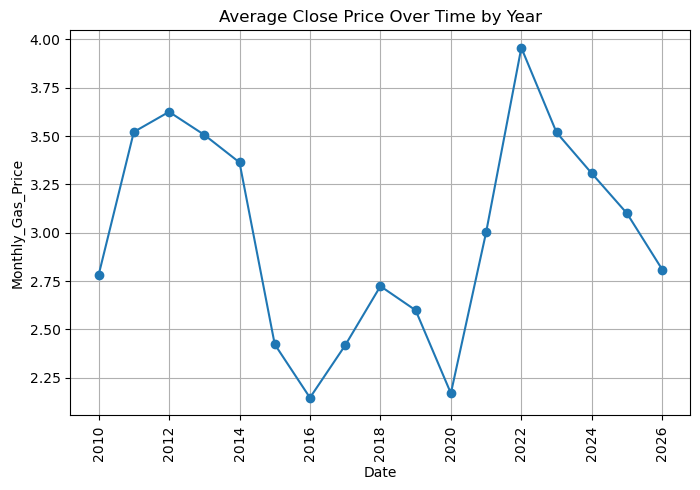

In [21]:
# Check sales over time for California by Year
df_cal_yearly = master_df.groupby(by='Year').agg({'Monthly_Gas_Price':'mean'}).reset_index()
plot_sales_over_time(df_cal_yearly, 'Year', 'Monthly_Gas_Price', 'Average Close Price Over Time by Year')

Average Monthly Gas Price Over Time by Year-Quarter


,Year_Quarter,Monthly_Gas_Price
0,2010Q1,2.710333
1,2010Q2,2.805333
2,2010Q3,2.721333
3,2010Q4,2.884333
4,2011Q1,3.289000


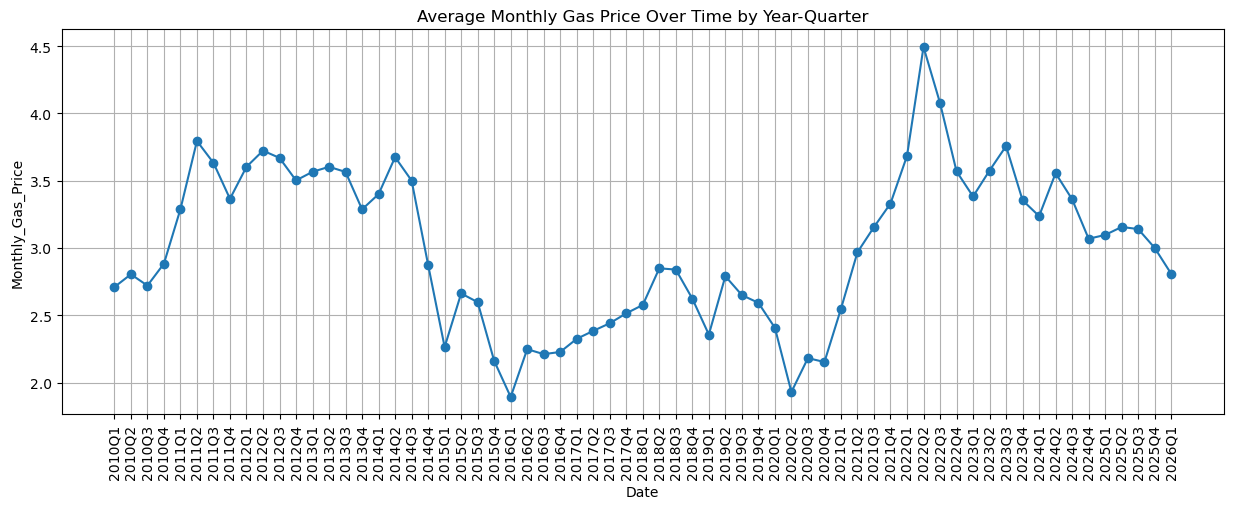

In [22]:
df_cal_quarter = master_df.groupby(by='Year_Quarter').agg({'Monthly_Gas_Price':'mean'}).reset_index()
plot_sales_over_time(df_cal_quarter, 'Year_Quarter', 'Monthly_Gas_Price', 'Average Monthly Gas Price Over Time by Year-Quarter', fig_size=(15,5))

Average Monthly Gas Price Over Time by Year Month


,Year_Month,Monthly_Gas_Price
0,2010-01,2.715
1,2010-02,2.644
2,2010-03,2.772
3,2010-04,2.848
4,2010-05,2.836


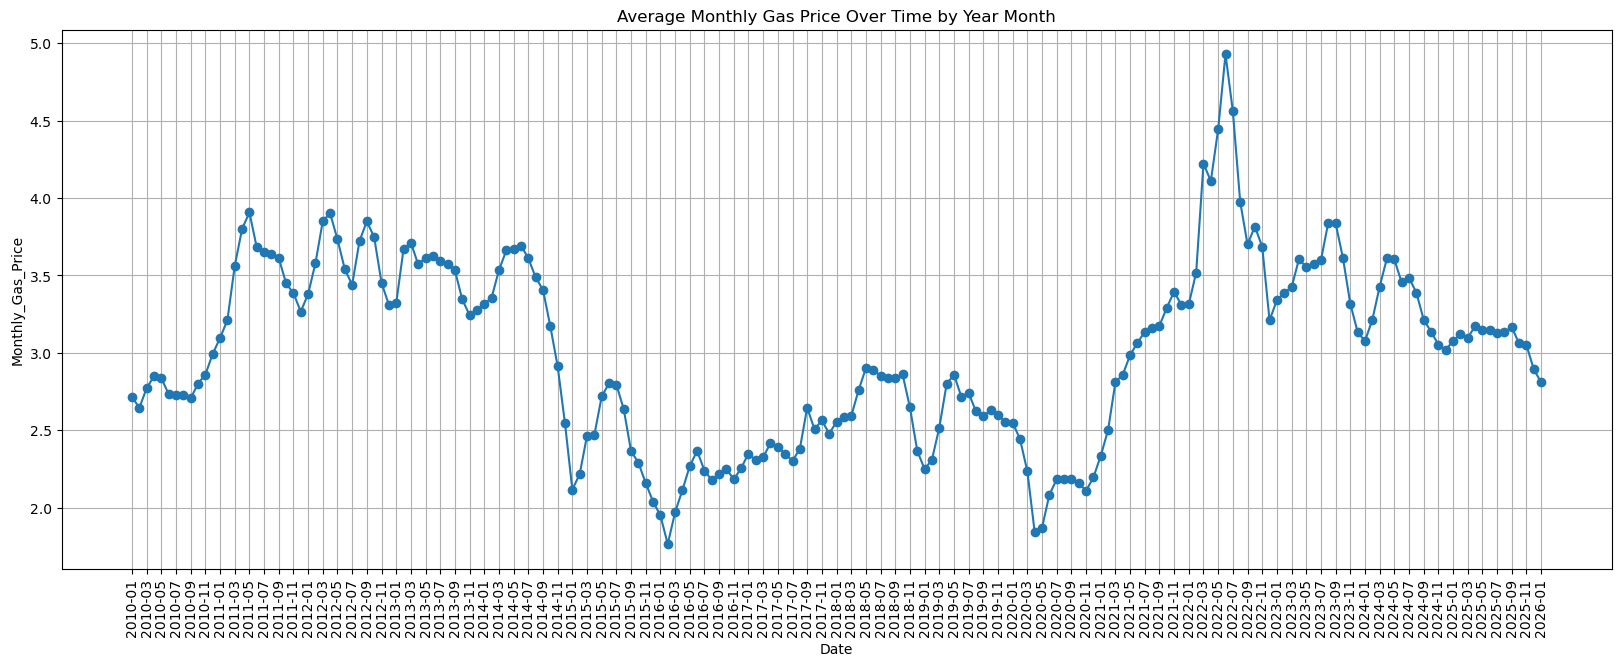

In [23]:
df_cal_monthly = master_df.groupby(by='Year_Month').agg({'Monthly_Gas_Price':'mean'}).reset_index()
# x-axis every 2 months for visualization purposes
range_xticks = df_cal_monthly['Year_Month'].unique()[::2]
# Call the function
plot_sales_over_time(df_cal_monthly, 'Year_Month', 'Monthly_Gas_Price', 'Average Monthly Gas Price Over Time by Year Month', fig_size=(20,7), range_xticks=range_xticks)

**Insights time series graphs**

* Plot average annual gasoline price: The average annual price from 2010 to 2026 didn't show a consistent trend during these 16 years, the price has been fluctuating during this period with upper and lower prices. For instance,  from 2012 to 2016, the price had a constant decrease, reaching its lowest value. After COVID, the price increased, reaching a maximum value in 2022, and decreased again until 2025, when we have a similar average annual price to 2010. 
* Plot average quarter gasoline price: These plots suggest a possible seasonal pattern in the data. We can see that over 16 years, the monthly gasoline price in Q2 of each year is the most expensive compared to the other quarters in the year, followed by a decrease or stability in price, except for 2010, 2017, and the COVID period. This pattern will be confirmed using seasonal decomposition and a statistical test.
* Plot average monthly gasoline price: Displays a very similar behaviour to the annual and quarter average price, with constant months of upper and lower trends. The plot doesn't show any outliers, and the volatility level is very similar across time, except for 2021, when it tends to have more variance. We will consider additional exogenous variables that help us explain these changes in trends. 

Therefore, we propose further analyzing gasoline prices monthly; this is the optimal granularity for forecasting gasoline prices, which would help several industries in their price setting and budgeting processes.

### 4.2 Stationarity testing (ADF)

We will check if the time series is a stationary

In [24]:
def adf_report(series, series_name="series", alpha=0.05):
    result = adfuller(series.dropna())
    test_stat, p_value, used_lag, n_obs, crit_vals, icbest = result

    print(f"\nADF test for {series_name}")
    print("----------------------------")
    print(f"Test statistic : {test_stat:.4f}")
    print(f"p-value        : {p_value:.4f}")
    print(f"Used lags      : {used_lag}")
    print(f"# of obs       : {n_obs}")
    print("Critical values:")
    for k, v in crit_vals.items():
        print(f"  {k}: {v:.4f}")

    print("\nInterpretation:")
    if p_value < alpha:
        print(f"  → p-value < {alpha}, reject H0 (unit root). Series is likely STATIONARY.")
    else:
        print(f"  → p-value ≥ {alpha}, fail to reject H0. Series is likely NONSTATIONARY.")

adf_report(master_df['Monthly_Gas_Price'], series_name="Monthly Gas Price")


ADF test for Monthly Gas Price
----------------------------
Test statistic : -2.4052
p-value        : 0.1403
Used lags      : 2
# of obs       : 190
Critical values:
  1%: -3.4652
  5%: -2.8769
  10%: -2.5749

Interpretation:
  → p-value ≥ 0.05, fail to reject H0. Series is likely NONSTATIONARY.


In [25]:
# Calculate first difference
df_diff_1 = master_df[['Monthly_Gas_Price']].copy()
df_diff_1['Monthly_Gas_Price_diff1'] = df_diff_1['Monthly_Gas_Price'].diff(1)
# drop the first month of 2010
df_diff_1 = df_diff_1.dropna()
adf_report(df_diff_1['Monthly_Gas_Price_diff1'], series_name="Monthly Gas Price First Difference")


ADF test for Monthly Gas Price First Difference
----------------------------
Test statistic : -4.6515
p-value        : 0.0001
Used lags      : 9
# of obs       : 182
Critical values:
  1%: -3.4668
  5%: -2.8776
  10%: -2.5753

Interpretation:
  → p-value < 0.05, reject H0 (unit root). Series is likely STATIONARY.


We can see that the Monthly Gas Price initial data is nonstationary, but after applying the first difference to the time series, we were able to reject the null hypothesis and obtain stationary data. It let us confirm that we need a model capable of first differencing, such as the Holt-Winters Triple, ARIMA, SARIMA, or a transfer function model, among other options.

### 4.3 Check Seasonal decompostion and ACF and PACF plots

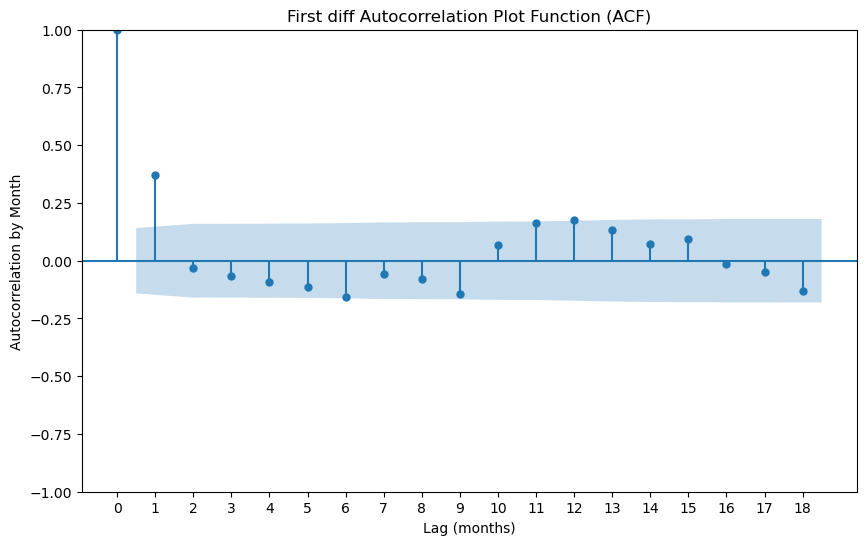

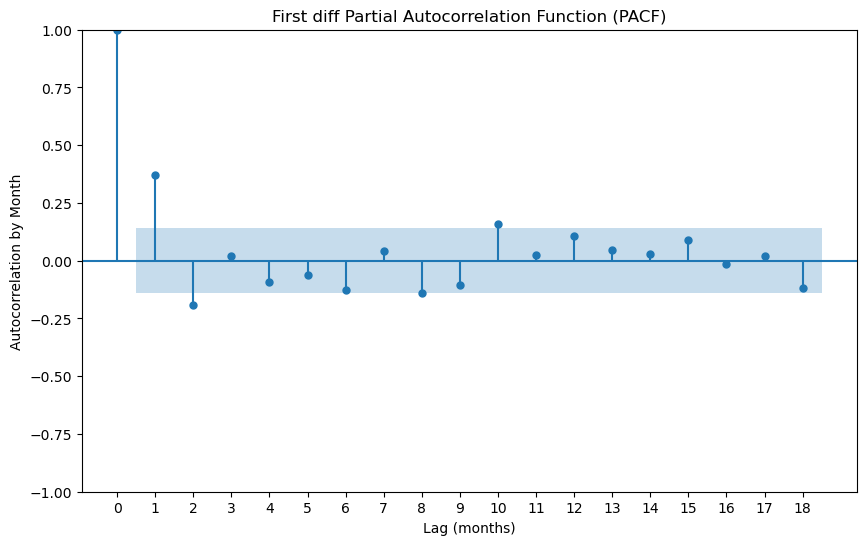

In [26]:
#Generate the autocorrelation plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(df_diff_1['Monthly_Gas_Price_diff1'], lags=18, ax=ax)
# Add titles and labels
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation by Month')
plt.title('First diff Autocorrelation Plot Function (ACF)')
plt.xticks(range(0,19))
plt.show()

#Generate the autocorrelation plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_pacf(df_diff_1['Monthly_Gas_Price_diff1'], lags=18, ax=ax)
# Add titles and labels
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation by Month')
plt.title('First diff Partial Autocorrelation Function (PACF)')
plt.xticks(range(0,19)) 
plt.show()

The **ACF** and **PCF**, display possible candidates outside the confidence interval, which are lags 1, 2, 6, 8, 10, 12, these apper to be the most significant months. It will be confirmed using the Ljun Box test to verify this visual insight.

**Ljung–Box test for autocorrelation**
* H0 (Null Hypothesis): No autocorrelation up to the specified lag.
* H1 (Alternative Hypothesis): There is autocorrelation up to the specified lag.

In [27]:
lb = acorr_ljungbox(df_diff_1['Monthly_Gas_Price_diff1'], lags=[1, 3, 2, 6, 10, 12], return_df=True)
display(lb)

,lb_stat,lb_pvalue
1,26.674374,2.407940e-07
3,27.734317,4.129590e-06
2,26.854965,1.474071e-06
6,36.979209,1.777398e-06
10,44.094184,3.165887e-06
12,55.855960,1.270526e-07


Considering a significant value of 0.05, **we reject the null hypothesis for all the lags**, indicating the presence of autocorrelation. The lags that are more important to be explored in a future ARIMA model are 1 and 12, which have the lowest p-value and the highest t-statistic.

Possible values for and baseline ARIMA model:
- p: 1, 2, 10 (based on PACF plot)
- d: 1 (based on ADF test)
- q: 1, 6, 12 (based on ACF plot)

### 4.4 Decomposition of Time Series

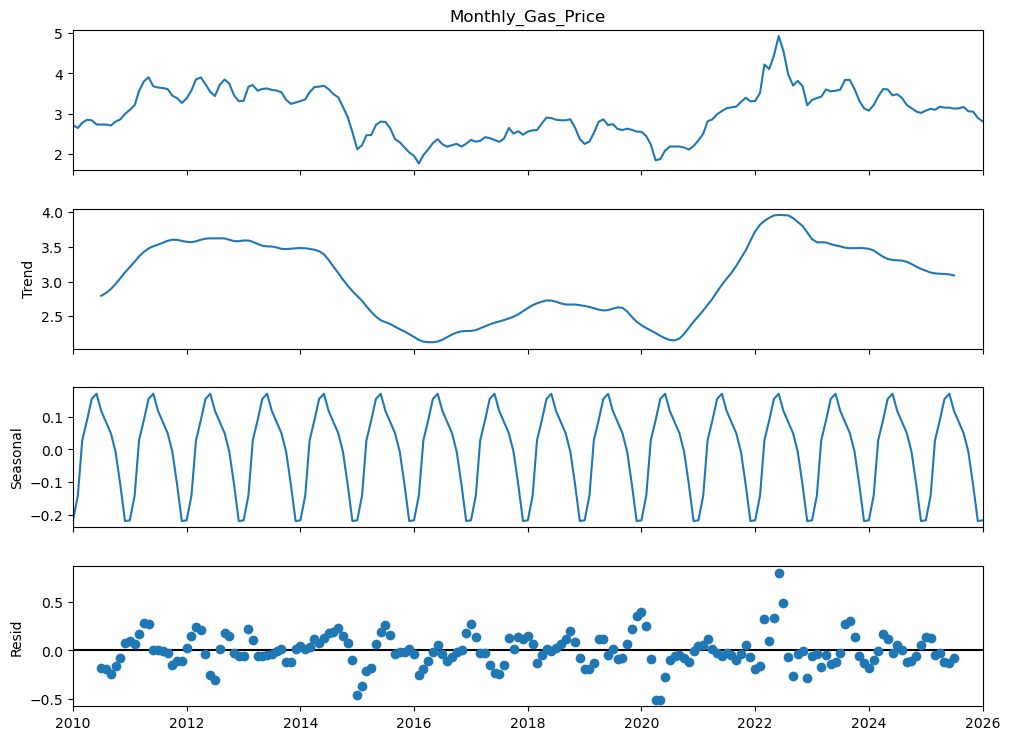

In [28]:
period = 12 # Annual Cycles seasonality with monthly data
decomp = seasonal_decompose(master_df['Monthly_Gas_Price'], model="additive", period=period)
fig = decomp.plot()
fig.set_size_inches(11, 8)
plt.show()

* Trend: As mentioned before, the monthly gasoline prices have upper and lower trends across the time series.
* Seasonal: The graph shows a clear annual seasonality, with peaks around the middle of the year (summer/Q2) and a decrease towards the last quarters of the year. 
* Residual: It displays a possible homoscedastic error (constant variance over time) with some outliers in 2020 and 2022, but it is not concerning as we can add exogenous variables to capture the outliers (e.g., COVID-19 dummy variable).

**Note**: An additive method was applied, since the seasonal fluctuations don't represent a multiplicative effect.

### 4.5 Explore exogenuos variables

In [29]:
# Possible exogenous variables to consider
master_df.columns

Index(['Gasoline_Stock', 'Monthly_Gas_Price', 'Weekly_Gas_Price',
       'Core_Sticky_CPI', 'oil_production', 'import_heavy_sour',
       'import_heavy_sweet', 'import_light_sour', 'import_light_sweet',
       'import_medium', 'miles_traveled_nsa', 'miles_traveled_sa',
       'total_imports', 'total_crude_supply', 'covid_dummy', 'Year',
       'Year_Quarter', 'Year_Month', 'Week'],
      dtype='str')

In [30]:
exo_vars = ['Gasoline_Stock', 'Weekly_Gas_Price',
       'Core_Sticky_CPI','oil_production' ,'import_heavy_sour', 'import_heavy_sweet',
       'import_light_sour', 'import_light_sweet', 'import_medium',
       'miles_traveled_nsa', 'miles_traveled_sa', 'total_imports', 'total_crude_supply', 'covid_dummy']

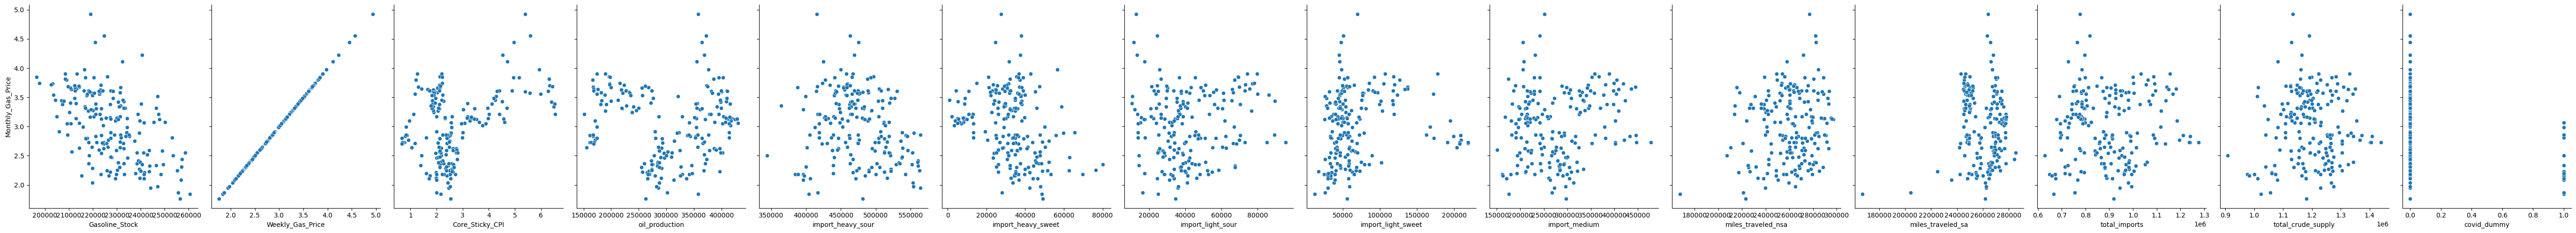

In [31]:
# Plots the target against multiple explanatory variables in one grid
import seaborn as sns
sns.pairplot(master_df, x_vars=exo_vars, y_vars=['Monthly_Gas_Price'], height=5, aspect=0.8)
plt.show()

In [32]:
# Linear correaltion using the pearson coefficient
df_aux = master_df[exo_vars + ['Monthly_Gas_Price']]
features = df_aux.corr()['Monthly_Gas_Price'].sort_values()
features

Gasoline_Stock       -0.542439
covid_dummy          -0.336470
import_heavy_sweet   -0.320268
import_heavy_sour    -0.212395
oil_production       -0.034833
total_crude_supply    0.021069
miles_traveled_sa     0.025169
total_imports         0.033467
import_light_sour     0.085806
import_light_sweet    0.140951
import_medium         0.150031
miles_traveled_nsa    0.157393
Core_Sticky_CPI       0.391916
Weekly_Gas_Price      1.000000
Monthly_Gas_Price     1.000000
Name: Monthly_Gas_Price, dtype: float64

<Axes: >

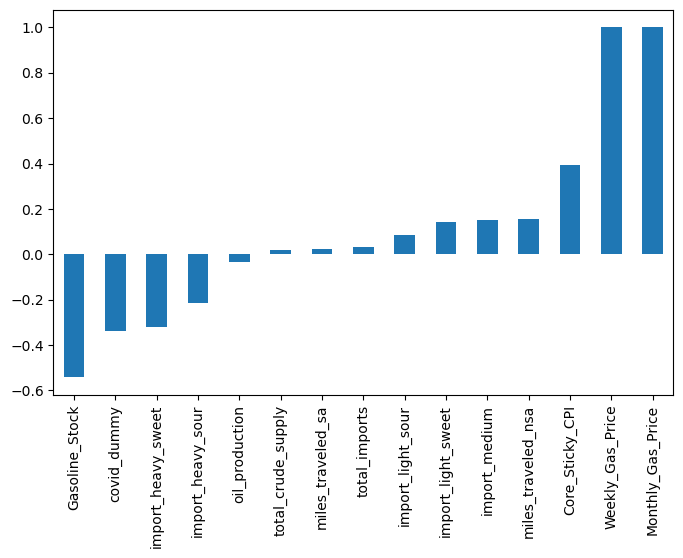

In [33]:
features.plot(kind='bar',figsize=(8,5))

Key variables with strong linear relationship with Monthly_Gas_Price: 

* Positive correlation: Core_sticky, miles_traveled_nsa, import_medium 
* Negative correlation: Gasoline_stock, covid_dummy,  import_heavy_sweet , import_heavy_sour

Next steps: we can apply Granger Causality Test to check in better way the correaltion of these variables.

## 5. Models

Functions

In [34]:
def plot_actual_vs_predicted(df, target_var, predicted_values, title, label_text, figsize=(10, 8)):
    # Plot Actual vs Predicted
    plt.figure(figsize=figsize)
    plt.plot(df.index, df[target_var], marker='o', label='Actual Sales', color='blue', alpha=0.6)
    plt.plot(df.index, df[predicted_values], marker='x', linestyle='--', label=label_text, color='red')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Monthly Gas Price')
    plt.legend()
    plt.xticks(rotation=90)
    plt.grid(True, alpha=0.2)
    plt.show()

def error_metrics(df, target_var, predicted_values):
    # Calculate error metrics
    # RMSE
    mse = mean_squared_error(df[target_var], df[predicted_values])
    rmse = np.sqrt(mse)
    # MAPE
    mape = mean_absolute_percentage_error(df[target_var], df[predicted_values])
    return rmse, mape

Establish training, test and holdout partitions

In [35]:
# Define train, test and holdout sets
train = master_df[(master_df.index <= '2022-12-01')]
test = master_df[(master_df.index >'2022-12-01') & (master_df.index <= '2024-12-01')]
holdout = master_df[master_df.index > '2024-12-01']

In [36]:
print('Train dataset shape:{}, min date {}, max date {}'.format(train.shape[0], train.index.min(), train.index.max()))
print('Test dataset shape:{}, min date {}, max date {}'.format(test.shape[0], test.index.min(), test.index.max()))
print('Holdout dataset shape:{}, min date {}, max date {}'.format(holdout.shape[0], holdout.index.min(), holdout.index.max()))

Train dataset shape:156, min date 2010-01-01 00:00:00, max date 2022-12-01 00:00:00
Test dataset shape:24, min date 2023-01-01 00:00:00, max date 2024-12-01 00:00:00
Holdout dataset shape:13, min date 2025-01-01 00:00:00, max date 2026-01-01 00:00:00


### 5.1 Model 1: ARIMA (Baseline)

We know the data must be differenciable at d=1, since the data set is non-stationary, but I became stationary at first difference as we verify using the ADF test.

In [37]:
# SARIMA parameters
# non-seasonal 
# p, d, q
# p = 2, according to PACF plot we can see a significant spike at lag 1 and 2, after the lag 2 the spkies stay in the confidence interval, which suggestes an AR(2) component. 
# d = from the ADF test we can see that the data is non-stationary so we will use d=1
# q = 1, accroding to ACF plot que can see a huge spike at lag 1, which suggests that a MA(1) component

# Analytical Note: The alternating positive-then-negative pattern in the PACF is actually a very common characteristic of an MA(1) process "tailing off." 
# This behavior in the PACF strongly reinforces the q=1 finding from your ACF plot.

sarima_order = (2, 1, 1)

model_sarima = SARIMAX(train['Monthly_Gas_Price'], 
                       order=sarima_order, 
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

sarima_res = model_sarima.fit(disp=False)

print("\nSARIMA summary:")
print(sarima_res.summary())


SARIMA summary:
                               SARIMAX Results                                
Dep. Variable:      Monthly_Gas_Price   No. Observations:                  156
Model:               SARIMAX(2, 1, 1)   Log Likelihood                  66.290
Date:                Wed, 04 Mar 2026   AIC                           -124.579
Time:                        16:02:45   BIC                           -112.458
Sample:                    01-01-2010   HQIC                          -119.655
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2491      0.253      0.984      0.325      -0.247       0.745
ar.L2         -0.1255      0.129     -0.971      0.332      -0.379       0.128
ma.L1          0.2363      0.262   

In [38]:
# We will apply a grid search to find the best combination of p and q based on AIC base on the possible combinations the PACF and ACF plot suggested.
initial_aic = 100000000
final_p = 0
final_q = 0

for p in [0,1,2]:
    for q in [0,1,2]:
        sarima_order = (p, 1, q)
        model_sarima = SARIMAX(train['Monthly_Gas_Price'], 
                               order=sarima_order, 
                               enforce_stationarity=False, 
                               enforce_invertibility=False)

        sarima_res = model_sarima.fit(disp=False)
        if sarima_res.aic < initial_aic:
            print('Current best ARIMA order: (p={}, d=1, q={}) with AIC: {:.2f}'.format(p, q, sarima_res.aic))
            initial_aic = sarima_res.aic
            final_p = p
            final_q = q
print(f"Best ARIMA order: (p={final_p}, d=1, q={final_q}) with AIC: {initial_aic:.2f}")

Current best ARIMA order: (p=0, d=1, q=0) with AIC: -100.11
Current best ARIMA order: (p=0, d=1, q=1) with AIC: -128.49
Best ARIMA order: (p=0, d=1, q=1) with AIC: -128.49


/opt/anaconda3/envs/ML1_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [39]:
# The AIC obtained a better AIC Score with p=0, d=1, q=1, which is have a better results against the initial  p=2, d=1, q=1. This suggests that the simpler ARIMA(0,1,1)

sarima_order = (0, 1, 1)

model_sarima = SARIMAX(train['Monthly_Gas_Price'], 
                       order=sarima_order, 
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

sarima_res = model_sarima.fit(disp=False)

print("\nSARIMA summary:")
print(sarima_res.summary())


SARIMA summary:
                               SARIMAX Results                                
Dep. Variable:      Monthly_Gas_Price   No. Observations:                  156
Model:               SARIMAX(0, 1, 1)   Log Likelihood                  66.243
Date:                Wed, 04 Mar 2026   AIC                           -128.486
Time:                        16:02:45   BIC                           -122.425
Sample:                    01-01-2010   HQIC                          -126.024
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4842      0.044     11.061      0.000       0.398       0.570
sigma2         0.0246      0.002     12.358      0.000       0.021       0.029
Ljung-Box (L1) (Q):                

In [40]:
# Generate Fitted Values
train['fitted_values_ARIMA'] = sarima_res.fittedvalues
# predicition values (3 weeks: aprox 37 months in test and holdout set)
forecast_result = sarima_res.forecast(steps=37)
test['forecast_values_ARIMA'] = forecast_result.values[:24]
holdout['forecast_values_ARIMA'] = forecast_result.values[24:]

In [41]:
dict_eror_metrics = {'Dataset':['Train (2022-2025)', 'Test (2 years)', 'Holdout (1 year)'],'RMSE':[], 'MAPE(%)':[]}

# Call the function to plot and calculate error metrics train data
RMSE, MAPE = error_metrics(train, 'Monthly_Gas_Price', 'fitted_values_ARIMA')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)

# Call the function to plot and calculate error metrics test data
RMSE, MAPE = error_metrics(test, 'Monthly_Gas_Price', 'forecast_values_ARIMA')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)

# Call the function to plot and calculate error metrics test data
RMSE, MAPE = error_metrics(holdout, 'Monthly_Gas_Price', 'forecast_values_ARIMA')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)



# Print the error metrics dictionary
df_error_metrics_ARIMA = pd.DataFrame(dict_eror_metrics)
print("\nError Metrics:")
display(df_error_metrics_ARIMA)



Error Metrics:


,Dataset,RMSE,MAPE(%)
0,Train (2022-2025),0.2675,4.48
1,Test (2 years),0.4457,10.85
2,Holdout (1 year),0.1147,3.36


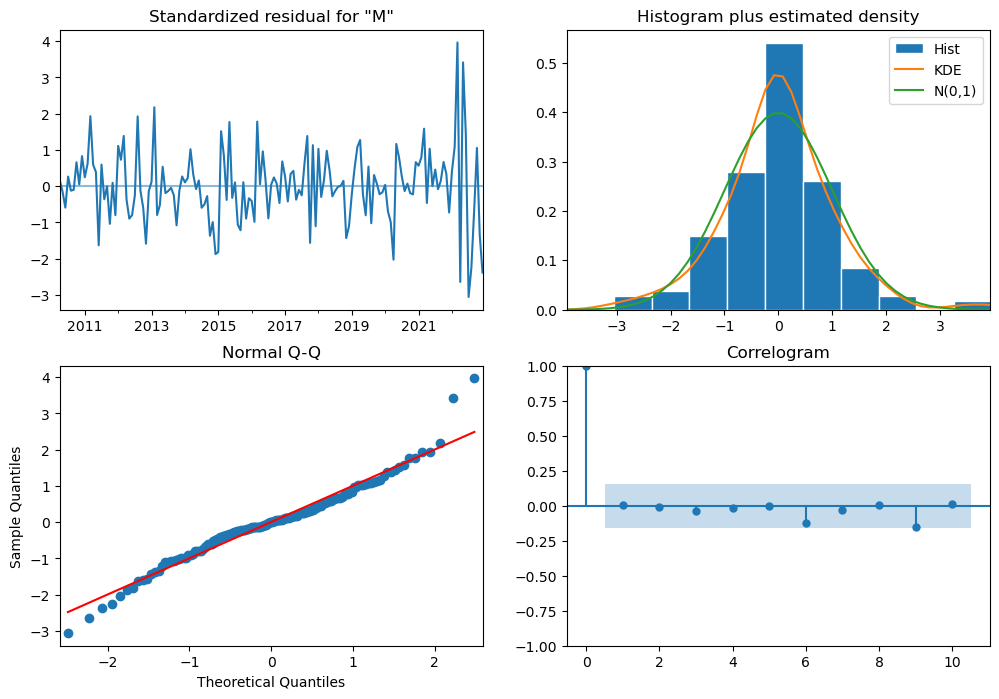

In [42]:
sarima_res.plot_diagnostics(figsize=(12, 8))
plt.show()

In [43]:
residuals = sarima_res.resid
lb = acorr_ljungbox(residuals, lags=[1,2, 3, 4], return_df=True)
display(lb)

,lb_stat,lb_pvalue
1,0.052797,0.818266
2,0.163571,0.921470
3,0.174988,0.981522
4,0.194193,0.995580


No autocorrelation of errors.

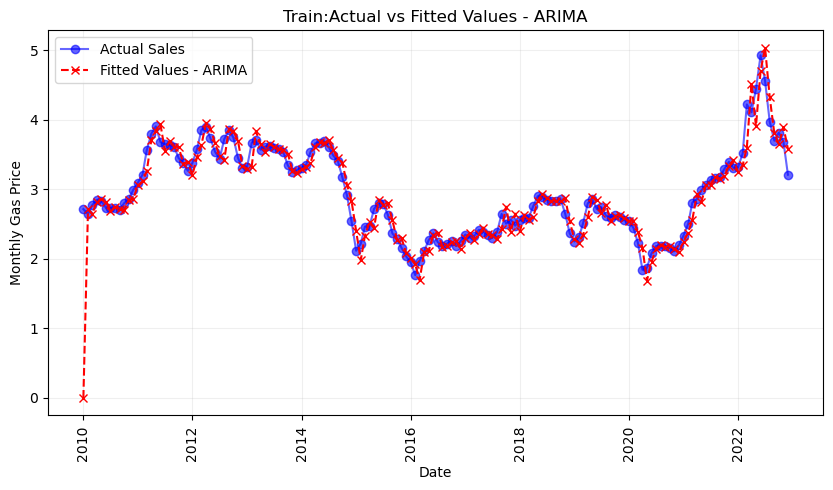

In [44]:
plot_actual_vs_predicted(train, 'Monthly_Gas_Price', 'fitted_values_ARIMA', 'Train:Actual vs Fitted Values - ARIMA', 'Fitted Values - ARIMA', figsize=(10,5))

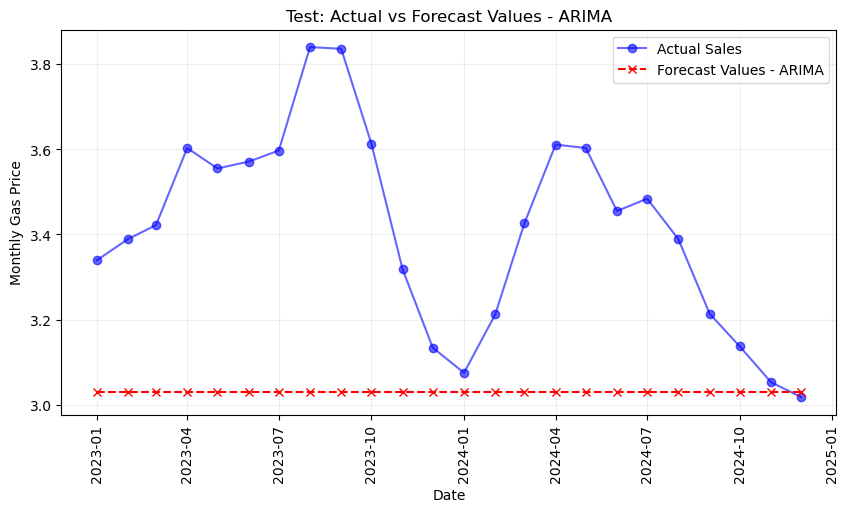

In [45]:
plot_actual_vs_predicted(test, 'Monthly_Gas_Price', 'forecast_values_ARIMA', 'Test: Actual vs Forecast Values - ARIMA', 'Forecast Values - ARIMA', figsize=(10,5))

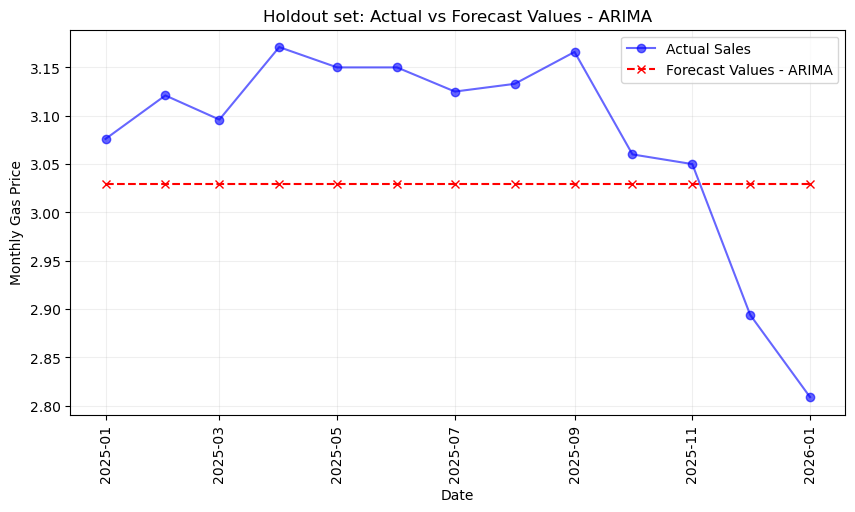

In [46]:
plot_actual_vs_predicted(holdout, 'Monthly_Gas_Price', 'forecast_values_ARIMA', 'Holdout set: Actual vs Forecast Values - ARIMA', 'Forecast Values - ARIMA', figsize=(10,5))

### 5.2 Model 2: SARIMA

We will create an initial model to establish the p,d,q parameters for the SARIMAX model using the ACF and PACF plots, without the upper trend and seasonality (Year bases)

1. Apply the first difference to remove the trend.
2. Use the P, D, Q, and s to control the year seasonality.

Establish the p,d,q and P,D,Q,S components

In [47]:
# SARIMA parameters
# non-seasonal 
# p, d, q
# p = 0, since our goal is to use the residuals to capture the p component of the model. 
# d = from the ADF test we can see that the data is non-stationary so we will use d=1
# q = 0, since our goal is to use the residuals to capture the q component of the model. 
sarima_order = (0, 1, 0)

# P,D,Q,S
# P = from the seasonal ACF we can see that the P=0
# D = from the seasonal differencing we can see that D=1, we cant to take out the sesaonal component of the weekly level of the data.
# Q = from the seasonal PACF we can see that Q=12
# s = The seasonal with period (Year level) S=12

sarima_seasonal = (0, 1, 0, 12)


model_sarima = SARIMAX(train['Monthly_Gas_Price'], 
                       order=sarima_order, 
                       seasonal_order=sarima_seasonal, 
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

sarima_res = model_sarima.fit(disp=False)

print("\nSARIMA summary:")
print(sarima_res.summary())


SARIMA summary:
                                     SARIMAX Results                                      
Dep. Variable:                  Monthly_Gas_Price   No. Observations:                  156
Model:             SARIMAX(0, 1, 0)x(0, 1, 0, 12)   Log Likelihood                  26.467
Date:                            Wed, 04 Mar 2026   AIC                            -50.935
Time:                                    16:02:45   BIC                            -47.979
Sample:                                01-01-2010   HQIC                           -49.734
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0403      0.004      9.691      0.000       0.032       0.048
Ljung-Box (L1) (Q)

Now we can use the model residuals to estimate the non-seasonal and seasonal components.

In [48]:
# Extract residuals
residuals = sarima_res.resid
# --- 3. Extract Residuals ---
# We slice from [13:] because the differencing (d=1 (trend), D=1 with s=12 (yearly seasonality)), causes the first 13 rows to be unstable/missing data.
residuals = residuals[13:]

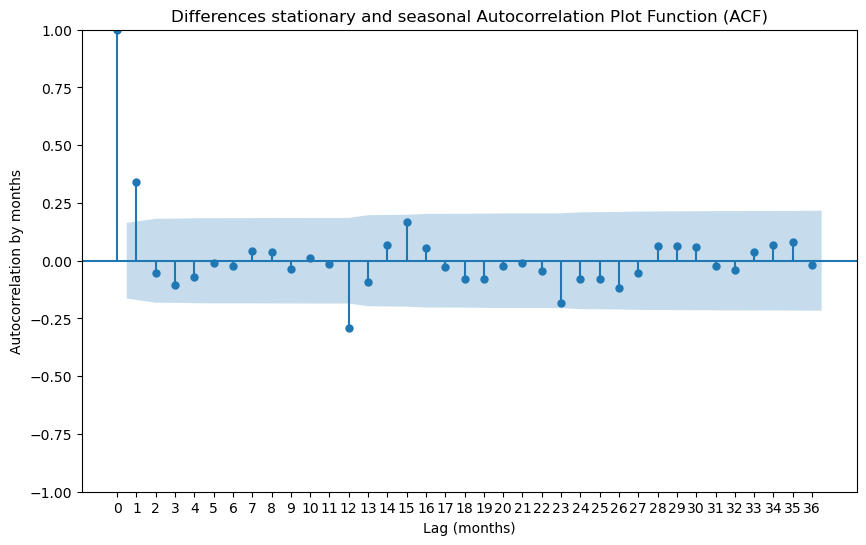

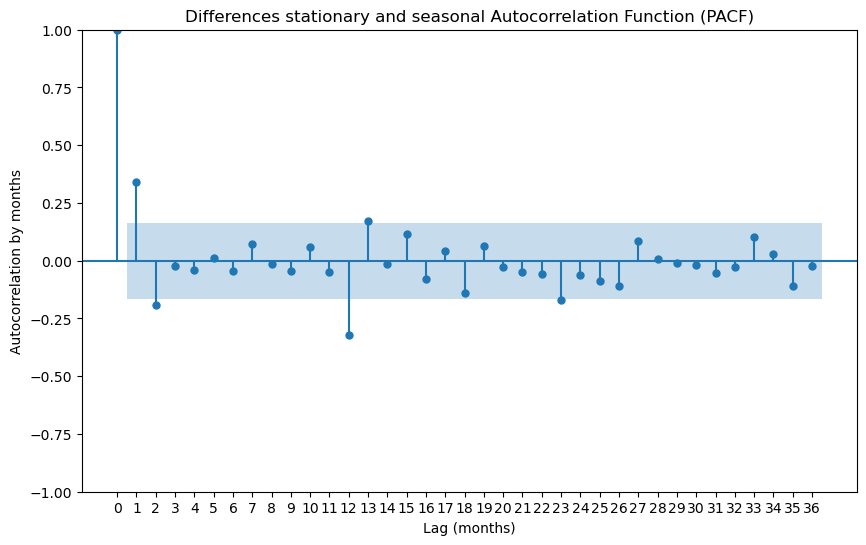

In [49]:
#Generate the autocorrelation plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(residuals, lags=36, ax=ax)
# Add titles and labels
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation by months')
plt.title('Differences stationary and seasonal Autocorrelation Plot Function (ACF)')
plt.xticks(range(0,37))
plt.show()

#Generate the autocorrelation plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_pacf(residuals, lags=36, ax=ax)
# Add titles and labels
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation by months')
plt.title('Differences stationary and seasonal Autocorrelation Function (PACF)')
plt.xticks(range(0,37)) 
plt.show()

non-seasonal components:
* p = 1 from the PACF plot huge lags at lag 1 and lag 7, after that the spikes stay in the confidence interval, which suggestes an AR(1) or AR(7) component.
* d = 1, from the ADF test we can see that the data is non-stationary so we will use d=1
* q = 1, from the ACF plot we can see a huge spike at lag 1 and lag 7, which suggests that a MA(1) or MA(7) component


seaosonal components:
* P = 0, according to the the seasonal PACF plot, where there is not significant spikes at lag 12,24,36, which suggest that there is not a seasonal AR component.
* D = 1, remove year seasonal component. 
* Q = 1, according to the the ACF plot, where the lag 12 have a signifcant spikes, afert that lag 24 or lag 36 are not significant outside the confidence interval.

In [50]:
# SARIMA parameters
# non-seasonal 
# p, d, q
sarima_order = (1, 1, 1)

# P,D,Q,S
sarima_seasonal = (0, 1, 1, 12)

# Exogenous features the dummy variables for the months of September, December, and January to control the first seasonal component in the model.

model_sarima = SARIMAX(train['Monthly_Gas_Price'], 
                       order=sarima_order, 
                       seasonal_order=sarima_seasonal, 
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

sarima_res = model_sarima.fit(disp=False)

print("\nSARIMA summary:")
print(sarima_res.summary())


SARIMA summary:
                                     SARIMAX Results                                      
Dep. Variable:                  Monthly_Gas_Price   No. Observations:                  156
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                  51.036
Date:                            Wed, 04 Mar 2026   AIC                            -94.072
Time:                                    16:02:45   BIC                            -82.633
Sample:                                01-01-2010   HQIC                           -89.424
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2129      0.107     -1.989      0.047      -0.423      -0.003
ma.L1          0.6

In [51]:
# Generate Fitted Values
train['fitted_values_SARIMA'] = sarima_res.fittedvalues
# predicition values (3 weeks: aprox 37 months in test and holdout set)
forecast_result = sarima_res.forecast(steps=37)
test['forecast_values_SARIMA'] = forecast_result.values[:24]
holdout['forecast_values_SARIMA'] = forecast_result.values[24:]

In [52]:
dict_eror_metrics = {'Dataset':['Train (2022-2025)', 'Test (2 years)', 'Holdout (1 year)'],'RMSE':[], 'MAPE(%)':[]}

# Call the function to plot and calculate error metrics train data
RMSE, MAPE = error_metrics(train, 'Monthly_Gas_Price', 'fitted_values_SARIMA')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)

# Call the function to plot and calculate error metrics test data
RMSE, MAPE = error_metrics(test, 'Monthly_Gas_Price', 'forecast_values_SARIMA')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)

# Call the function to plot and calculate error metrics test data
RMSE, MAPE = error_metrics(holdout, 'Monthly_Gas_Price', 'forecast_values_SARIMA')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)


# Print the error metrics dictionary
df_error_metrics_SARIMA = pd.DataFrame(dict_eror_metrics)
print("\nError Metrics:")
display(df_error_metrics_SARIMA)


Error Metrics:


,Dataset,RMSE,MAPE(%)
0,Train (2022-2025),0.2996,5.02
1,Test (2 years),0.2178,5.19
2,Holdout (1 year),0.5030,15.83


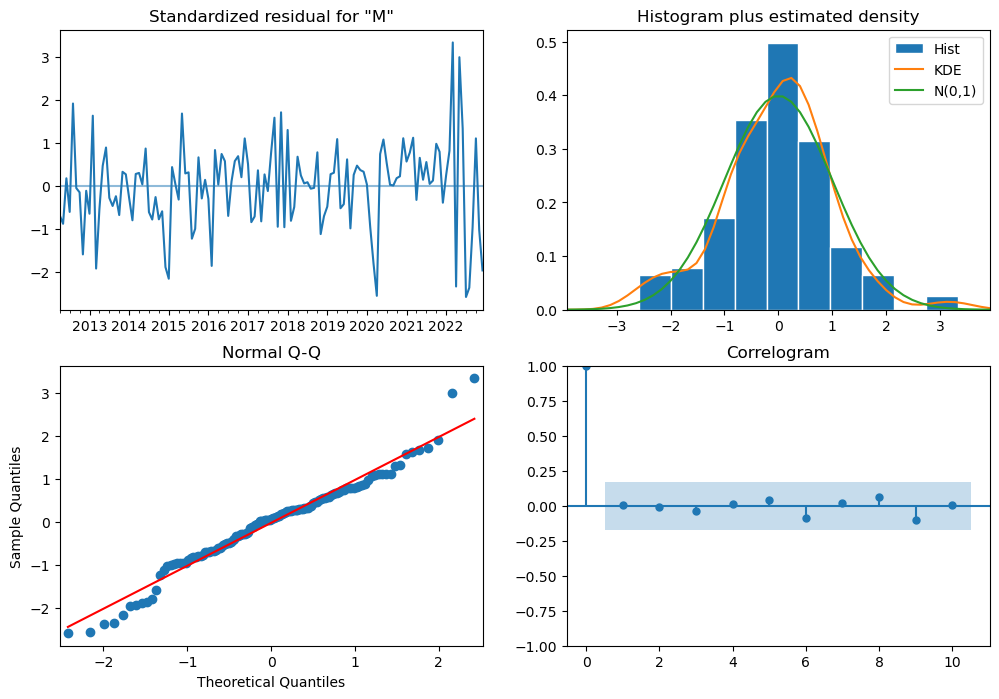

In [53]:
sarima_res.plot_diagnostics(figsize=(12, 8))
plt.show()

In [54]:
residuals = sarima_res.resid
lb = acorr_ljungbox(residuals, lags=[1,2, 3, 4], return_df=True)
display(lb)

,lb_stat,lb_pvalue
1,0.017080,0.896020
2,0.049434,0.975586
3,0.147887,0.985528
4,0.147906,0.997397


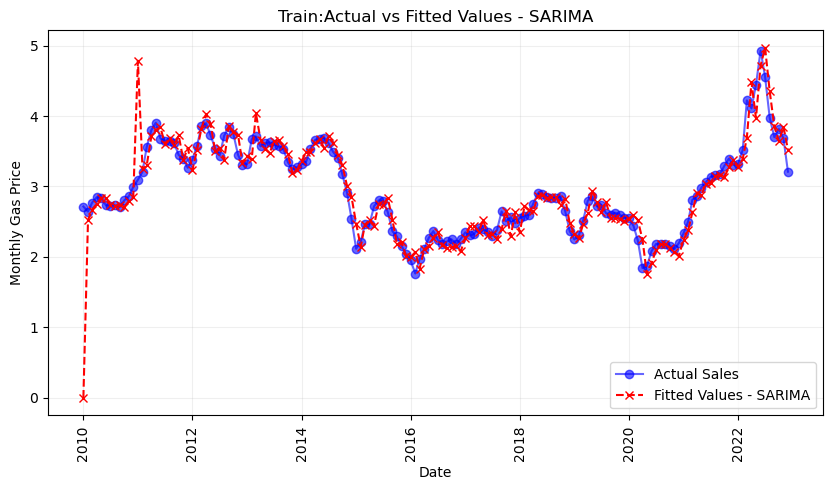

In [55]:
plot_actual_vs_predicted(train, 'Monthly_Gas_Price', 'fitted_values_SARIMA', 'Train:Actual vs Fitted Values - SARIMA', 'Fitted Values - SARIMA', figsize=(10,5))

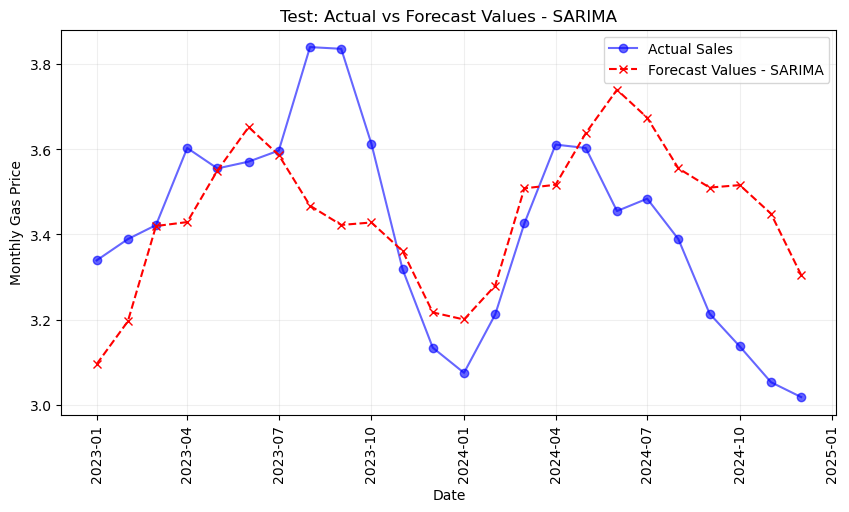

In [56]:
plot_actual_vs_predicted(test, 'Monthly_Gas_Price', 'forecast_values_SARIMA', 'Test: Actual vs Forecast Values - SARIMA', 'Forecast Values - SARIMA', figsize=(10,5))

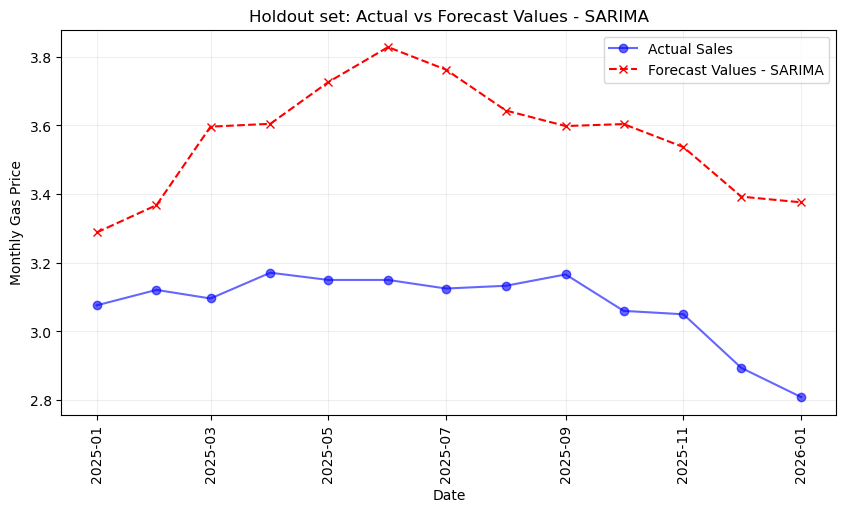

In [57]:
plot_actual_vs_predicted(holdout, 'Monthly_Gas_Price', 'forecast_values_SARIMA', 'Holdout set: Actual vs Forecast Values - SARIMA', 'Forecast Values - SARIMA', figsize=(10,5))

### 5.3 Model 3: SARIMAX

We will add the exogenous variables to the SARIMA model to see if we can improve the performance of the model.

We will use the top 3 positive and negatve variabels that have the higher pearson correlation 

In [58]:
# Linear correaltion using the pearson coefficient
df_aux = master_df[exo_vars + ['Monthly_Gas_Price']]
features = df_aux.corr()['Monthly_Gas_Price'].sort_values()
features

Gasoline_Stock       -0.542439
covid_dummy          -0.336470
import_heavy_sweet   -0.320268
import_heavy_sour    -0.212395
oil_production       -0.034833
total_crude_supply    0.021069
miles_traveled_sa     0.025169
total_imports         0.033467
import_light_sour     0.085806
import_light_sweet    0.140951
import_medium         0.150031
miles_traveled_nsa    0.157393
Core_Sticky_CPI       0.391916
Weekly_Gas_Price      1.000000
Monthly_Gas_Price     1.000000
Name: Monthly_Gas_Price, dtype: float64

In [59]:
exo_vars_selected = ['covid_dummy', 'Core_Sticky_CPI']

# Negative correlation:
# 'Gasoline_Stock': NO
# 'import_heavy_sweet': NO
# 'import_heavy_sour': NO
# 'oil_production': NO
# 'total_crude_supply': NO

# Positive correlation:
# 'Core_Sticky_CPI': NO
# 'miles_traveled_nsa': NO
# 'import_medium': NO
# 'import_light_sweet': NO


#'import_heavy_sweet', 'import_heavy_sour','Core_Sticky_CPI','miles_traveled_nsa','import_medium'

Similar process as before, fit a simpler SARIMAX components and exogenous variables to capture the AR and MA components in the residuals for non-seasonal and seasonal components.

In [60]:
# SARIMA parameters
# non-seasonal 
sarima_order = (0, 1, 0)

# P,D,Q,S

sarima_seasonal = (0, 1, 0, 12)


model_sarima = SARIMAX(train['Monthly_Gas_Price'], 
                       order=sarima_order, 
                       seasonal_order=sarima_seasonal, 
                        exog=train[exo_vars_selected],
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

sarima_res = model_sarima.fit(disp=False)

print("\nSARIMA summary:")
print(sarima_res.summary())


SARIMA summary:
                                     SARIMAX Results                                      
Dep. Variable:                  Monthly_Gas_Price   No. Observations:                  156
Model:             SARIMAX(0, 1, 0)x(0, 1, 0, 12)   Log Likelihood                  34.705
Date:                            Wed, 04 Mar 2026   AIC                            -63.409
Time:                                    16:02:46   BIC                            -54.542
Sample:                                01-01-2010   HQIC                           -59.806
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
covid_dummy        -0.3520      0.105     -3.340      0.001      -0.558      -0.145
Cor

In [61]:
# Extract residuals
residuals = sarima_res.resid
# --- 3. Extract Residuals ---
# We slice from [13:] because the differencing (d=1 (trend), D=1 with s=12 (yearly seasonality)), causes the first 13 rows to be unstable/missing data.
residuals = residuals[13:]

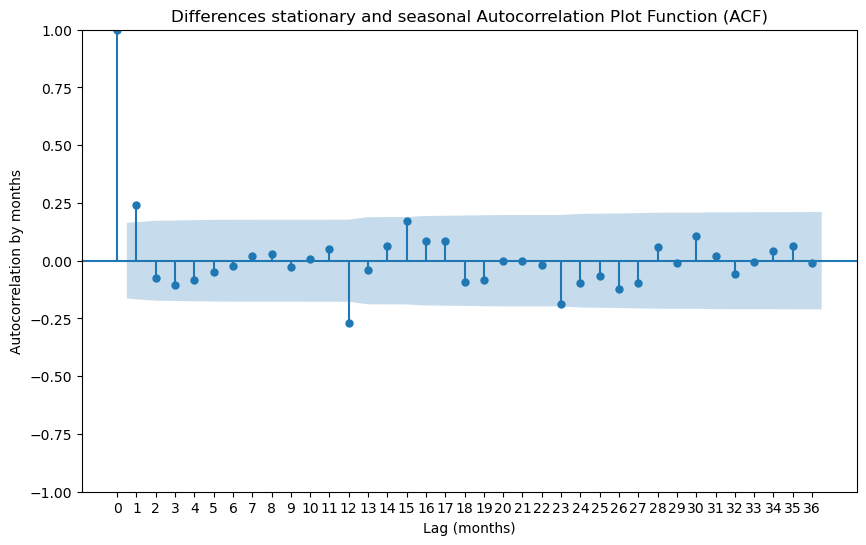

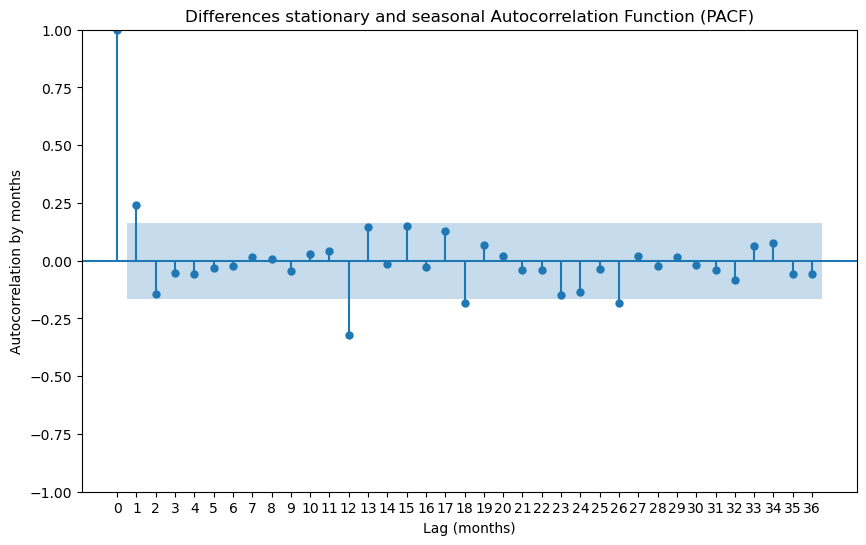

In [62]:
#Generate the autocorrelation plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(residuals, lags=36, ax=ax)
# Add titles and labels
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation by months')
plt.title('Differences stationary and seasonal Autocorrelation Plot Function (ACF)')
plt.xticks(range(0,37))
plt.show()

#Generate the autocorrelation plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_pacf(residuals, lags=36, ax=ax)
# Add titles and labels
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation by months')
plt.title('Differences stationary and seasonal Autocorrelation Function (PACF)')
plt.xticks(range(0,37)) 
plt.show()

non-seasonal components:
* p = 1 from the PACF plot huge lags at lag 1 and lag 7, after that the spikes stay in the confidence interval, which suggestes an AR(1) or AR(7) component.
* d = 1, from the ADF test we can see that the data is non-stationary so we will use d=1
* q = 1, from the ACF plot we can see a huge spike at lag 1 and lag 7, which suggests that a MA(1) or MA(7) component


seaosonal components:
* P = 0, according to the the seasonal PACF plot, where there is not significant spikes at lag 12,24,36, which suggest that there is not a seasonal AR component.
* D = 1, remove year seasonal component. 
* Q = 1, according to the the ACF plot, where the lag 12 have a signifcant spikes, afert that lag 24 or lag 36 are not significant outside the confidence interval.

In [63]:
# SARIMA parameters
# non-seasonal 
# p, d, q
sarima_order = (1, 1, 1)

# P,D,Q,S
sarima_seasonal = (0, 1, 1, 12)

exo_vars_selected = ['covid_dummy', 'Core_Sticky_CPI']

# Exogenous features the dummy variables for the months of September, December, and January to control the first seasonal component in the model.

model_sarima = SARIMAX(train['Monthly_Gas_Price'], 
                       order=sarima_order, 
                       seasonal_order=sarima_seasonal, 
                        exog=train[exo_vars_selected],
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

sarima_res = model_sarima.fit(disp=False)

print("\nSARIMA summary:")
print(sarima_res.summary())


SARIMA summary:
                                     SARIMAX Results                                      
Dep. Variable:                  Monthly_Gas_Price   No. Observations:                  156
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                  53.230
Date:                            Wed, 04 Mar 2026   AIC                            -94.459
Time:                                    16:02:46   BIC                            -77.300
Sample:                                01-01-2010   HQIC                           -87.487
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
covid_dummy        -0.1845      0.119     -1.551      0.121      -0.418       0.049
Cor

In [64]:
# Generate Fitted Values
train['fitted_values_SARIMAX'] = sarima_res.fittedvalues
# predicition values (3 weeks: aprox 37 months in test and holdout set)
# append exogenous variables for the forecast period (test + holdout)
df_exgo_forecast = pd.concat([test[exo_vars_selected], holdout[exo_vars_selected]])
forecast_result = sarima_res.forecast(steps=37, exog=df_exgo_forecast)
test['forecast_values_SARIMAX'] = forecast_result.values[:24]
holdout['forecast_values_SARIMAX'] = forecast_result.values[24:]

In [65]:
dict_eror_metrics = {'Dataset':['Train (2022-2025)', 'Test (2 years)', 'Holdout (1 year)'],'RMSE':[], 'MAPE(%)':[]}

# Call the function to plot and calculate error metrics train data
RMSE, MAPE = error_metrics(train, 'Monthly_Gas_Price', 'fitted_values_SARIMAX')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)

# Call the function to plot and calculate error metrics test data
RMSE, MAPE = error_metrics(test, 'Monthly_Gas_Price', 'forecast_values_SARIMAX')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)

# Call the function to plot and calculate error metrics test data
RMSE, MAPE = error_metrics(holdout, 'Monthly_Gas_Price', 'forecast_values_SARIMAX')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)


# Print the error metrics dictionary
df_error_metrics_SARIMAX = pd.DataFrame(dict_eror_metrics)
print("\nError Metrics:")
display(df_error_metrics_SARIMAX)


Error Metrics:


,Dataset,RMSE,MAPE(%)
0,Train (2022-2025),0.2868,5.01
1,Test (2 years),0.3087,7.57
2,Holdout (1 year),0.2332,6.71


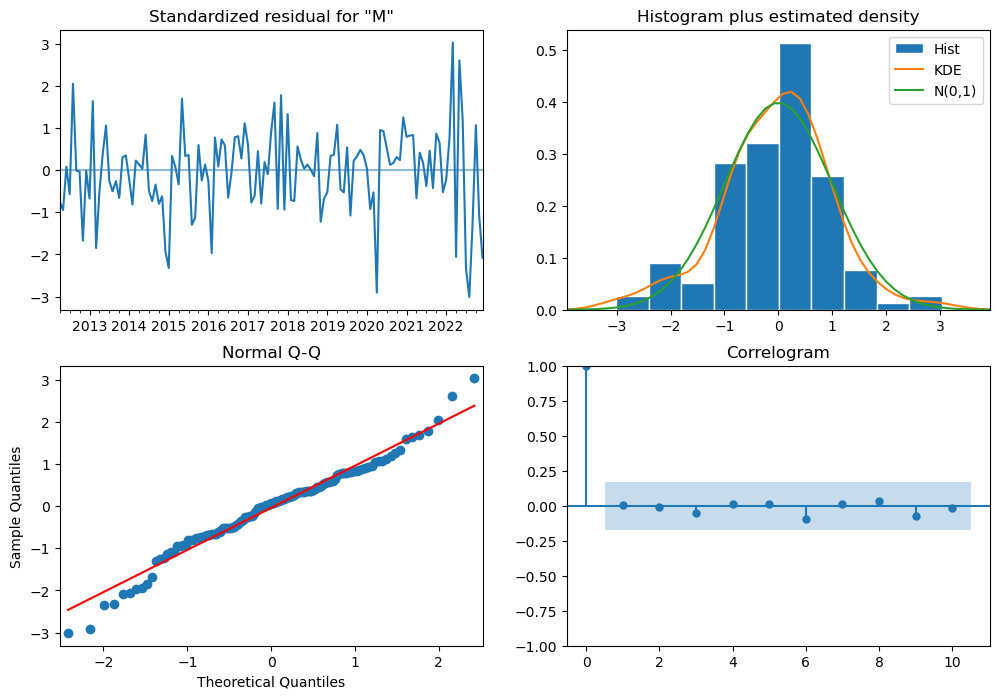

In [66]:
sarima_res.plot_diagnostics(figsize=(12, 8))
plt.show()

In [67]:
residuals = sarima_res.resid
lb = acorr_ljungbox(residuals, lags=[1,2, 3, 4], return_df=True)
display(lb)

,lb_stat,lb_pvalue
1,0.322792,0.569935
2,0.348974,0.839888
3,0.474775,0.924397
4,0.475498,0.975842


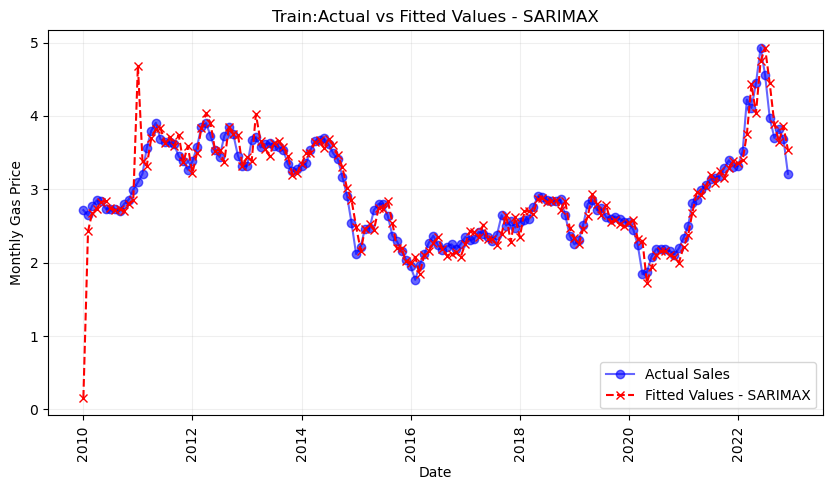

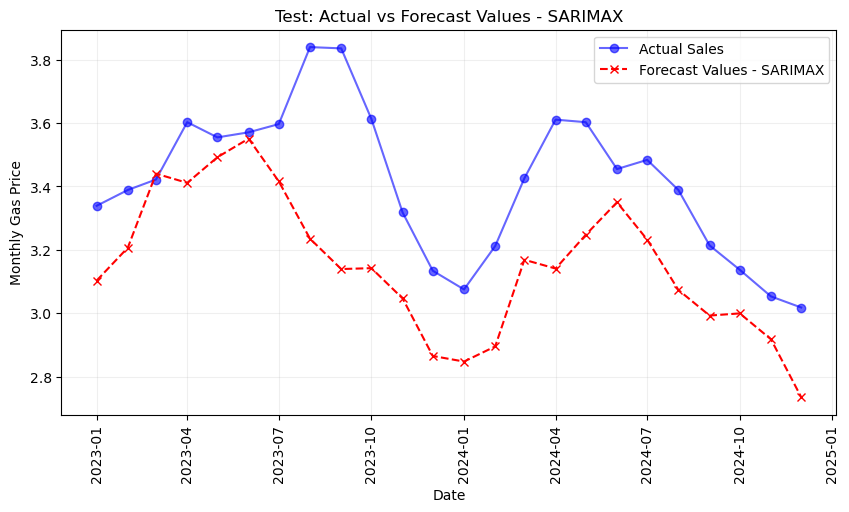

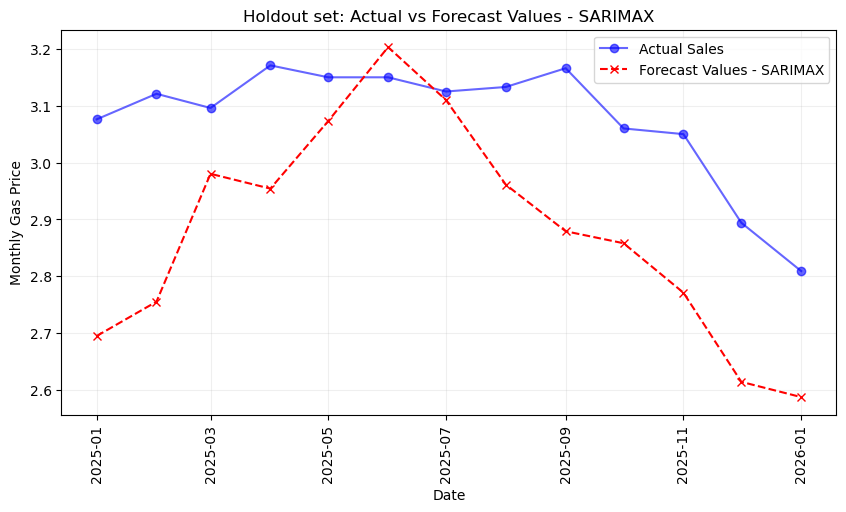

In [68]:
plot_actual_vs_predicted(train, 'Monthly_Gas_Price', 'fitted_values_SARIMAX', 'Train:Actual vs Fitted Values - SARIMAX', 'Fitted Values - SARIMAX', figsize=(10,5))
plot_actual_vs_predicted(test, 'Monthly_Gas_Price', 'forecast_values_SARIMAX', 'Test: Actual vs Forecast Values - SARIMAX', 'Forecast Values - SARIMAX', figsize=(10,5))
plot_actual_vs_predicted(holdout, 'Monthly_Gas_Price', 'forecast_values_SARIMAX', 'Holdout set: Actual vs Forecast Values - SARIMAX', 'Forecast Values - SARIMAX', figsize=(10,5))

### 5.4 Model 4: Transfer Function with ARIMA Errors (ARIMAX)

Apply the granger causality test to see if.
* Null Hypothesis ($H_0$): The time series X does not Granger-cause the time series in the Y.
* Null Hypothesis ($H_a$): The time series X the have a Granger-cause the time series in the Y.


Note: Granger causality tests assume that both of your time series are stationary

In [69]:
# Calculate first and seasonal difference
df_diff_seasonal = train.copy()
df_diff_seasonal['Monthly_Gas_Price_diff_13'] = df_diff_seasonal['Monthly_Gas_Price'].diff(1).diff(12)
# drop the first month of 2010
df_diff_seasonal = df_diff_seasonal.dropna()
adf_report(df_diff_seasonal['Monthly_Gas_Price_diff_13'], series_name="Monthly Gas Price First Difference")


ADF test for Monthly Gas Price First Difference
----------------------------
Test statistic : -3.1209
p-value        : 0.0250
Used lags      : 12
# of obs       : 130
Critical values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

Interpretation:
  → p-value < 0.05, reject H0 (unit root). Series is likely STATIONARY.


In [70]:
# Negative correlation:
# 'Gasoline_Stock': NO
# 'import_heavy_sweet': NO
# 'import_heavy_sour': NO
# 'oil_production': NO
# 'total_crude_supply': NO

# Positive correlation:
# 'Core_Sticky_CPI': NO
# 'miles_traveled_nsa': NO
# 'import_medium': NO
# 'import_light_sweet': NO

In [71]:
# Linear correaltion using the pearson coefficient
df_aux = master_df[exo_vars + ['Monthly_Gas_Price']]
features = df_aux.corr()['Monthly_Gas_Price'].sort_values()
features

Gasoline_Stock       -0.542439
covid_dummy          -0.336470
import_heavy_sweet   -0.320268
import_heavy_sour    -0.212395
oil_production       -0.034833
total_crude_supply    0.021069
miles_traveled_sa     0.025169
total_imports         0.033467
import_light_sour     0.085806
import_light_sweet    0.140951
import_medium         0.150031
miles_traveled_nsa    0.157393
Core_Sticky_CPI       0.391916
Weekly_Gas_Price      1.000000
Monthly_Gas_Price     1.000000
Name: Monthly_Gas_Price, dtype: float64

In [72]:
print("Testing Granger causality test:")
# Define the maximum number of lags to test
maxlag = 4
test_exogenous = ['Gasoline_Stock','import_heavy_sweet','import_heavy_sour','oil_production','total_crude_supply',
                  'Core_Sticky_CPI','miles_traveled_nsa','import_medium','import_light_sweet']
for exo in test_exogenous:
    print('Testing variable: {}'.format(exo))
    grangercausalitytests(df_diff_seasonal[['Monthly_Gas_Price_diff_13', exo]], maxlag=maxlag)
    print("\n\n")

Testing Granger causality test:
Testing variable: Gasoline_Stock

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.7219  , p=0.1012  , df_denom=139, df_num=1
ssr based chi2 test:   chi2=2.7807  , p=0.0954  , df=1
likelihood ratio test: chi2=2.7538  , p=0.0970  , df=1
parameter F test:         F=2.7219  , p=0.1012  , df_denom=139, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.5290  , p=0.2205  , df_denom=136, df_num=2
ssr based chi2 test:   chi2=3.1704  , p=0.2049  , df=2
likelihood ratio test: chi2=3.1353  , p=0.2085  , df=2
parameter F test:         F=1.5290  , p=0.2205  , df_denom=136, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.0197  , p=0.3861  , df_denom=133, df_num=3
ssr based chi2 test:   chi2=3.2202  , p=0.3589  , df=3
likelihood ratio test: chi2=3.1837  , p=0.3642  , df=3
parameter F test:         F=1.0197  , p=0.3861  , df_denom=133, df_num=3

Granger Causality
number of 

In [73]:
# After the test the only relevant variable that Granger cause the target variable is the 'Core_Sticky_CPI', which is also the variable with the highest positive correlation with the target variable.
# Run the test again wih this variable and with 10 lags to capture the annual seasonality component of the data.

# Define the maximum number of lags to test
maxlag = 10
test_result = grangercausalitytests(df_diff_seasonal[['Monthly_Gas_Price_diff_13', 'Core_Sticky_CPI']], maxlag=10)



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.1651  , p=0.0246  , df_denom=139, df_num=1
ssr based chi2 test:   chi2=5.2766  , p=0.0216  , df=1
likelihood ratio test: chi2=5.1809  , p=0.0228  , df=1
parameter F test:         F=5.1651  , p=0.0246  , df_denom=139, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.2725  , p=0.0159  , df_denom=136, df_num=2
ssr based chi2 test:   chi2=8.8591  , p=0.0119  , df=2
likelihood ratio test: chi2=8.5919  , p=0.0136  , df=2
parameter F test:         F=4.2725  , p=0.0159  , df_denom=136, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.8419  , p=0.0112  , df_denom=133, df_num=3
ssr based chi2 test:   chi2=12.1323 , p=0.0069  , df=3
likelihood ratio test: chi2=11.6352 , p=0.0087  , df=3
parameter F test:         F=3.8419  , p=0.0112  , df_denom=133, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.7817  , p=0.0294  

We can see that the 10 lags are significant for this variable, we will test several lags in the model

Similar process as before, fit a simpler SARIMAX components and exogenous variables to capture the AR and MA components in the residuals for non-seasonal and seasonal components.

In [74]:
# SARIMA parameters
# non-seasonal 
sarima_order = (1, 1, 1)

# P,D,Q,S
sarima_seasonal = (0, 1, 1, 12)

# lags compotents for the model
train['Core_Sticky_CPI_lag1'] = train['Core_Sticky_CPI'].shift(1)
#train['Core_Sticky_CPI_lag2'] = train['Core_Sticky_CPI'].shift(2)
#train['Core_Sticky_CPI_lag3'] = train['Core_Sticky_CPI'].shift(3)
#train['Core_Sticky_CPI_lag4'] = train['Core_Sticky_CPI'].shift(4)
train_2 = train.dropna()

exo_vars_selected = ['covid_dummy', 'Core_Sticky_CPI', 'Core_Sticky_CPI_lag1']

model_sarima = SARIMAX(train_2['Monthly_Gas_Price'], 
                       order=sarima_order, 
                       seasonal_order=sarima_seasonal, 
                        exog=train_2[exo_vars_selected],
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

sarima_res = model_sarima.fit(disp=False)

print("\nSARIMA summary:")
print(sarima_res.summary())


SARIMA summary:
                                     SARIMAX Results                                      
Dep. Variable:                  Monthly_Gas_Price   No. Observations:                  155
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                  52.179
Date:                            Wed, 04 Mar 2026   AIC                            -90.359
Time:                                    16:02:47   BIC                            -70.394
Sample:                                02-01-2010   HQIC                           -82.247
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
covid_dummy             -0.1785      0.119     -1.506      0.132      -0.411 

In [75]:
train

,Gasoline_Stock,Monthly_Gas_Price,Weekly_Gas_Price,Core_Sticky_CPI,oil_production,import_heavy_sour,import_heavy_sweet,import_light_sour,import_light_sweet,import_medium,...,total_crude_supply,covid_dummy,Year,Year_Quarter,Year_Month,Week,fitted_values_ARIMA,fitted_values_SARIMA,fitted_values_SARIMAX,Core_Sticky_CPI_lag1
2010-01-01,225636.60,2.715,2.71500,1.170764,167529.0,430340.0,30820.0,66372.0,219020.0,351720.0,...,1265801.0,0,2010,2010Q1,2010-01,53,0.000000,0.000000,0.157464,NaN
2010-02-01,231405.75,2.644,2.64400,1.048684,155496.0,401212.0,28848.0,55060.0,203584.0,323896.0,...,1168096.0,0,2010,2010Q1,2010-02,5,2.715000,2.522331,2.425733,1.170764
2010-03-01,226422.25,2.772,2.77160,0.925503,170976.0,475960.0,20468.0,69724.0,209576.0,420404.0,...,1367108.0,0,2010,2010Q1,2010-03,9,2.644000,2.671874,2.678676,1.048684
2010-04-01,223452.80,2.848,2.84825,0.869413,161769.0,461592.0,24848.0,70352.0,208680.0,445872.0,...,1373113.0,0,2010,2010Q2,2010-04,13,2.822209,2.755286,2.732736,0.925503
2010-05-01,221144.25,2.836,2.83620,0.793302,167427.0,518760.0,28408.0,62404.0,199528.0,432484.0,...,1409011.0,0,2010,2010Q2,2010-05,17,2.859956,2.841577,2.828998,0.869413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-01,216528.00,3.975,3.97500,5.936758,376168.0,449440.0,56556.0,25716.0,48400.0,205188.0,...,1161468.0,0,2022,2022Q3,2022-08,31,4.326916,4.352061,4.446762,5.584768
2022-09-01,212421.20,3.700,3.70025,6.330953,372876.0,462964.0,25636.0,24468.0,49732.0,189480.0,...,1125156.0,0,2022,2022Q3,2022-09,35,3.804587,3.853778,3.895716,5.936758
2022-10-01,208343.25,3.815,3.81520,6.310663,385700.0,487724.0,32108.0,26460.0,52292.0,175104.0,...,1159388.0,0,2022,2022Q4,2022-10,39,3.649354,3.640143,3.647939,6.330953
2022-11-01,209609.75,3.685,3.68500,6.430141,374794.0,415992.0,47296.0,21324.0,59076.0,206640.0,...,1125122.0,0,2022,2022Q4,2022-11,44,3.895213,3.848557,3.856243,6.310663


In [76]:
# Caculate lag of Core_Sticky_CPI_lag1 (add last value of train to test to calculate the lag for the first month of the test set)
test = pd.concat([train.iloc[-1:], test])
test['Core_Sticky_CPI_lag1'] = test['Core_Sticky_CPI'].shift(1)
test = test.dropna(subset=['Core_Sticky_CPI_lag1'])
# Caculate lag of Core_Sticky_CPI_lag1 (add last value of test to holdout to calculate the lag for the first month of the test set)
holdout = pd.concat([test.iloc[-1:], holdout])
holdout['Core_Sticky_CPI_lag1'] = holdout['Core_Sticky_CPI'].shift(1)
holdout = holdout.dropna(subset=['Core_Sticky_CPI_lag1'])

In [77]:
test.shape

(24, 26)

In [78]:
holdout.shape

(13, 26)

In [79]:
# Generate Fitted Values
train_2['fitted_values_transFunc'] = sarima_res.fittedvalues
# predicition values (3 weeks: aprox 35 months in test and holdout set)
df_exgo_forecast = pd.concat([test[exo_vars_selected], holdout[exo_vars_selected]])
# Assumption: append exogenous variables for the forecast period (test + holdout + duplicate last row holdout to calculate the lag)
df_exgo_forecast = pd.concat([df_exgo_forecast, holdout[exo_vars_selected].iloc[-1:]])
forecast_result = sarima_res.forecast(steps=38, exog=df_exgo_forecast)
test['forecast_values_transFunc'] = forecast_result.values[:24]
holdout['forecast_values_transFunc'] = forecast_result.values[24]

In [80]:
dict_eror_metrics = {'Dataset':['Train (2022-2025)', 'Test (2 years)', 'Holdout (1 year)'],'RMSE':[], 'MAPE(%)':[]}

# Call the function to plot and calculate error metrics train data
RMSE, MAPE = error_metrics(train_2, 'Monthly_Gas_Price', 'fitted_values_transFunc')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)

# Call the function to plot and calculate error metrics test data
RMSE, MAPE = error_metrics(test, 'Monthly_Gas_Price', 'forecast_values_transFunc')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)

# Call the function to plot and calculate error metrics test data
RMSE, MAPE = error_metrics(holdout, 'Monthly_Gas_Price', 'forecast_values_transFunc')
dict_eror_metrics['RMSE'].append(round(RMSE,4))
dict_eror_metrics['MAPE(%)'].append(round(MAPE,4)*100)


# Print the error metrics dictionary
df_error_metrics_Trans_Func = pd.DataFrame(dict_eror_metrics)
print("\nError Metrics:")
display(df_error_metrics_Trans_Func)


Error Metrics:


,Dataset,RMSE,MAPE(%)
0,Train (2022-2025),0.2806,4.97
1,Test (2 years),0.3782,9.75
2,Holdout (1 year),0.5306,16.81


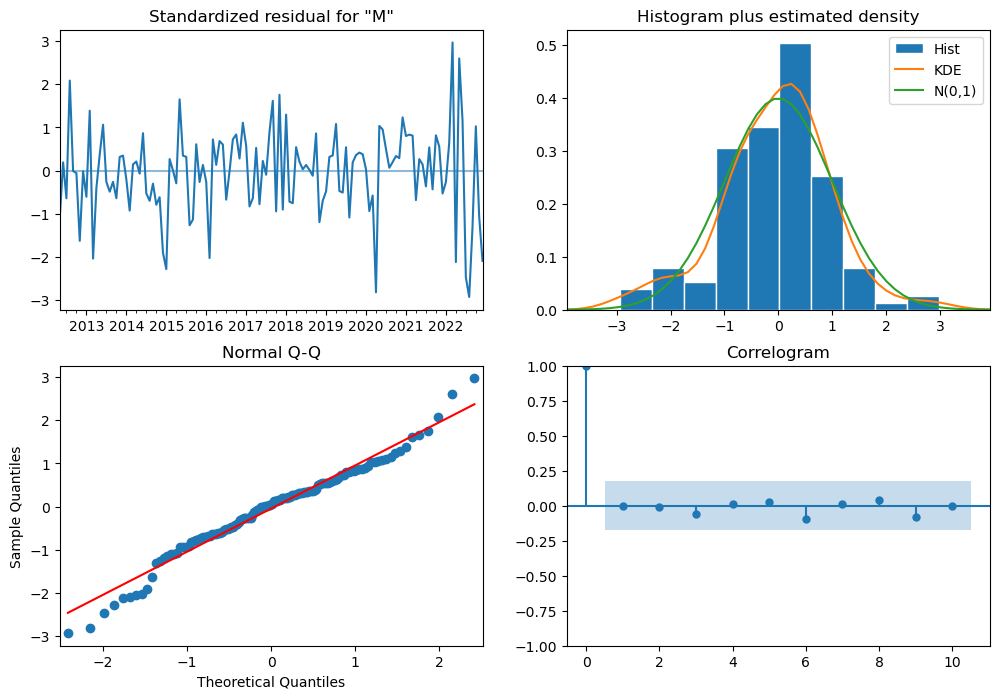

In [81]:
sarima_res.plot_diagnostics(figsize=(12, 8))
plt.show()

In [82]:
residuals = sarima_res.resid
lb = acorr_ljungbox(residuals, lags=[1,2, 3, 4], return_df=True)
display(lb)

,lb_stat,lb_pvalue
1,0.884091,0.347084
2,0.944292,0.623662
3,1.117805,0.772778
4,1.129187,0.889614


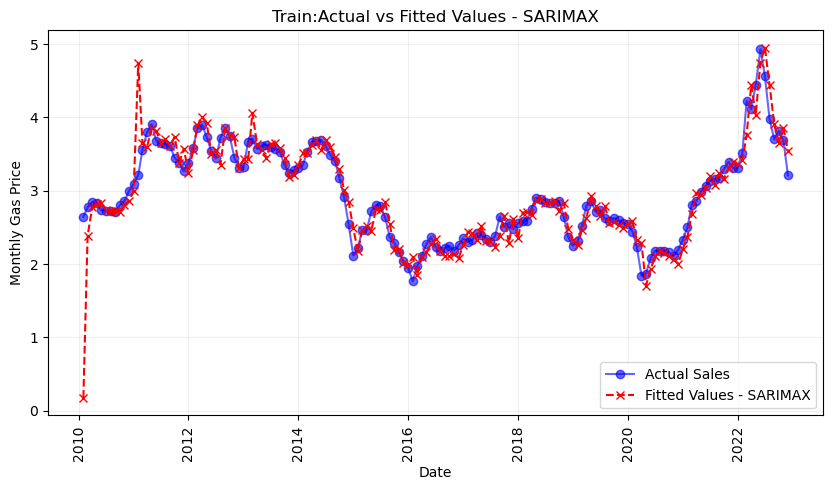

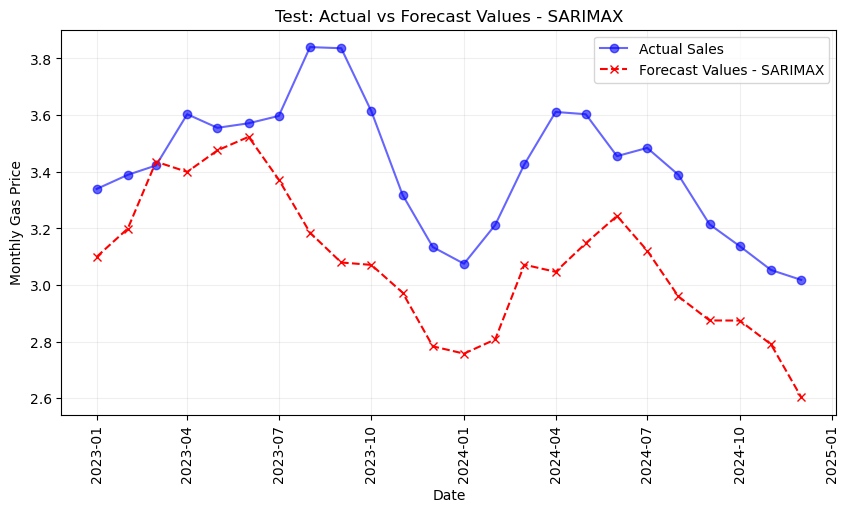

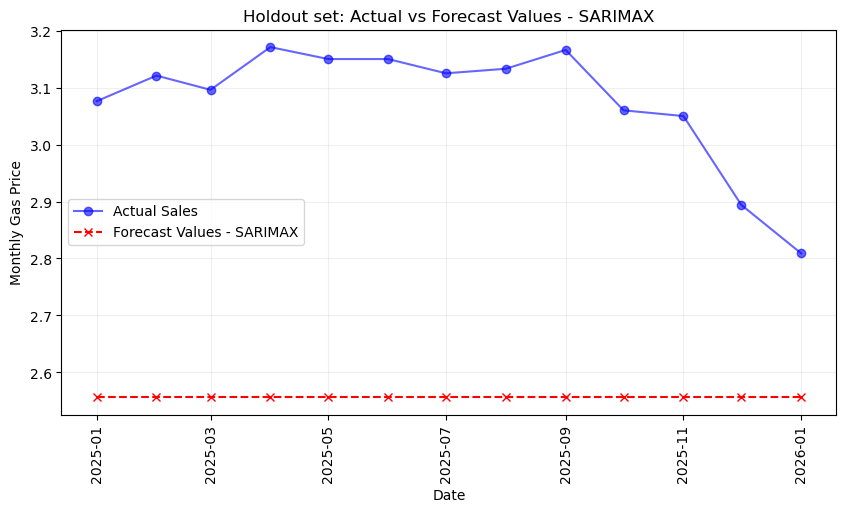

In [83]:
plot_actual_vs_predicted(train_2, 'Monthly_Gas_Price', 'fitted_values_transFunc', 'Train:Actual vs Fitted Values - SARIMAX', 'Fitted Values - SARIMAX', figsize=(10,5))
plot_actual_vs_predicted(test, 'Monthly_Gas_Price', 'forecast_values_transFunc', 'Test: Actual vs Forecast Values - SARIMAX', 'Forecast Values - SARIMAX', figsize=(10,5))
plot_actual_vs_predicted(holdout, 'Monthly_Gas_Price', 'forecast_values_transFunc', 'Holdout set: Actual vs Forecast Values - SARIMAX', 'Forecast Values - SARIMAX', figsize=(10,5))

## 6. Compare approaches

In [84]:
print('Modelo 1 ARIMA (Baseline):')
display(df_error_metrics_ARIMA)
print('Modelo 2 SARIMA:')
display(df_error_metrics_SARIMA)
print('Modelo 3 SARIMAX:')
display(df_error_metrics_SARIMAX)
print('Modelo 4 Transfer Function with SARIMAX:')
display(df_error_metrics_Trans_Func)

Modelo 1 ARIMA (Baseline):


,Dataset,RMSE,MAPE(%)
0,Train (2022-2025),0.2675,4.48
1,Test (2 years),0.4457,10.85
2,Holdout (1 year),0.1147,3.36


Modelo 2 SARIMA:


,Dataset,RMSE,MAPE(%)
0,Train (2022-2025),0.2996,5.02
1,Test (2 years),0.2178,5.19
2,Holdout (1 year),0.5030,15.83


Modelo 3 SARIMAX:


,Dataset,RMSE,MAPE(%)
0,Train (2022-2025),0.2868,5.01
1,Test (2 years),0.3087,7.57
2,Holdout (1 year),0.2332,6.71


Modelo 4 Transfer Function with SARIMAX:


,Dataset,RMSE,MAPE(%)
0,Train (2022-2025),0.2806,4.97
1,Test (2 years),0.3782,9.75
2,Holdout (1 year),0.5306,16.81
